<a href="https://colab.research.google.com/" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Deep Learning-Based Hand Gesture Recognition Using Convolutional Neural Networks**


**Dataset:** [LeapGestRecog](https://www.kaggle.com/datasets/gti-upm/leapgestrecog) —
20,000 near-infrared images of **10 hand gesture classes** captured with a Leap Motion sensor.  
Each image is **240×640 px** (resized to **64×64** for training). This is the most widely used
benchmark for gesture recognition with CNNs and has a clean, balanced class structure.




In [ ]:
! pip install kaggle -q
! mkdir -p ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json
print("Kaggle API configured ✓")


Kaggle API configured ✓


**Download the LeapGestRecog dataset from Kaggle and unzip it:**

In [ ]:
! kaggle datasets download -d gti-upm/leapgestrecog


Dataset URL: https://www.kaggle.com/datasets/gti-upm/leapgestrecog
License(s): CC-BY-NC-SA-4.0
100% 2.13G/2.13G [00:15<00:00, 149MB/s]



In [ ]:
! unzip -q leapgestrecog.zip -d leapgestrecog
! ls leapgestrecog/leapGestRecog/


00  01	02  03	04  05	06  07	08  09


# Importing Necessary Libraries
<hr>


In [ ]:
import os, cv2, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model, model_from_json
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPool2D, MaxPooling2D, ZeroPadding2D, Flatten, Dense,
    Dropout, BatchNormalization, Activation, GlobalAveragePooling2D,
    DepthwiseConv2D, Add, Multiply, Reshape
)
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:


DATASET_PATH = 'leapgestrecog/leapGestRecog'
IMG_SIZE     = 64

GESTURES = {
    '01_palm':       0,
    '02_l':          1,
    '03_fist':       2,
    '04_fist_moved': 3,
    '05_thumb':      4,
    '06_index':      5,
    '07_ok':         6,
    '08_palm_moved': 7,
    '09_c':          8,
    '10_down':       9,
}
GESTURE_NAMES = {v: k.split('_',1)[1].replace('_',' ').title() for k,v in GESTURES.items()}

records = []
for subject in sorted(os.listdir(DATASET_PATH)):
    subject_path = os.path.join(DATASET_PATH, subject)
    if not os.path.isdir(subject_path):
        continue
    for gesture_folder in sorted(os.listdir(subject_path)):
        label = GESTURES.get(gesture_folder)
        if label is None:
            continue
        gesture_path = os.path.join(subject_path, gesture_folder)
        for img_file in os.listdir(gesture_path):
            if img_file.lower().endswith(('.png','.jpg','.jpeg')):
                records.append({
                    'filepath': os.path.join(gesture_path, img_file),
                    'label':    label,
                    'subject':  subject,
                    'gesture':  gesture_folder
                })

df = pd.DataFrame(records)
print(f"Total images found : {len(df)}")
print(f"Gesture classes    : {df['label'].nunique()}")
df.head(5)


Total images found : 20000
Gesture classes    : 10


,filepath,label,subject,gesture
0,leapgestrecog/leapGestRecog/00/01_palm/frame_0...,0,00,01_palm
1,leapgestrecog/leapGestRecog/00/01_palm/frame_0...,0,00,01_palm
2,leapgestrecog/leapGestRecog/00/01_palm/frame_0...,0,00,01_palm
3,leapgestrecog/leapGestRecog/00/01_palm/frame_0...,0,00,01_palm
4,leapgestrecog/leapGestRecog/00/01_palm/frame_0...,0,00,01_palm


# **Exploratory Data Analysis**


In [ ]:

print("Shape:", df.shape)
print("\nNull values:", df.isna().sum().sum())
print("\nColumn info:")
df.info()
print("\nLabel distribution:")
print(df['label'].value_counts().sort_index())


Shape: (20000, 4)

Null values: 0

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filepath  20000 non-null  object
 1   label     20000 non-null  int64 
 2   subject   20000 non-null  object
 3   gesture   20000 non-null  object
dtypes: int64(1), object(3)
memory usage: 625.1+ KB

Label distribution:
label
0    2000
1    2000
2    2000
3    2000
4    2000
5    2000
6    2000
7    2000
8    2000
9    2000
Name: count, dtype: int64


In [ ]:

print("Gesture ID → Name mapping:")
for k,v in GESTURE_NAMES.items():
    print(f"  {k:>2} → {v}")


Gesture ID → Name mapping:
   0 → Palm
   1 → L
   2 → Fist
   3 → Fist Moved
   4 → Thumb
   5 → Index
   6 → Ok
   7 → Palm Moved
   8 → C
   9 → Down


## Images per Subject × Gesture (Grouped Bar)



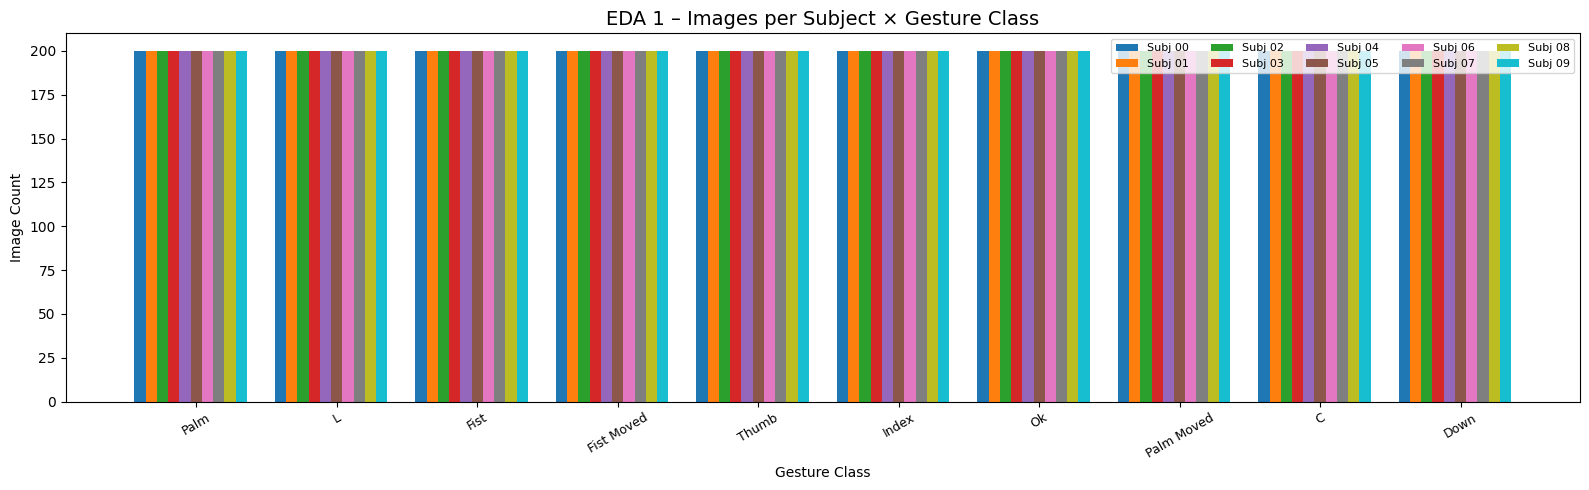


Pivot – Subject vs Gesture (image counts):
gesture  01_palm  02_l  03_fist  04_fist_moved  05_thumb  06_index  07_ok  08_palm_moved  09_c  10_down
subject                                                                                                
00           200   200      200            200       200       200    200            200   200      200
01           200   200      200            200       200       200    200            200   200      200
02           200   200      200            200       200       200    200            200   200      200
03           200   200      200            200       200       200    200            200   200      200
04           200   200      200            200       200       200    200            200   200      200
05           200   200      200            200       200       200    200            200   200      200
06           200   200      200            200       200       200    200            200   200      200
07           200   2

In [ ]:

subjects  = sorted(df['subject'].unique())
n_subj    = len(subjects)
x         = np.arange(10)
width     = 0.08
cmap      = plt.cm.tab10(np.linspace(0, 1, n_subj))

fig, ax = plt.subplots(figsize=(16, 5))
for idx, subj in enumerate(subjects):
    counts = [df[(df['subject']==subj) & (df['label']==g)].shape[0] for g in range(10)]
    ax.bar(x + idx*width, counts, width, label=f'Subj {subj}', color=cmap[idx])

ax.set_xticks(x + width*n_subj/2)
ax.set_xticklabels([GESTURE_NAMES[i] for i in range(10)], rotation=30, fontsize=9)
ax.set_title('EDA 1 – Images per Subject × Gesture Class', fontsize=14)
ax.set_xlabel('Gesture Class'); ax.set_ylabel('Image Count')
ax.legend(ncol=5, fontsize=8, loc='upper right')
plt.tight_layout(); plt.show()

# Also print the pivot table
pivot = pd.crosstab(df['subject'], df['gesture'])
print("\nPivot – Subject vs Gesture (image counts):")
print(pivot.to_string())


## Gesture Pair Confusion Potential (Similarity Score)


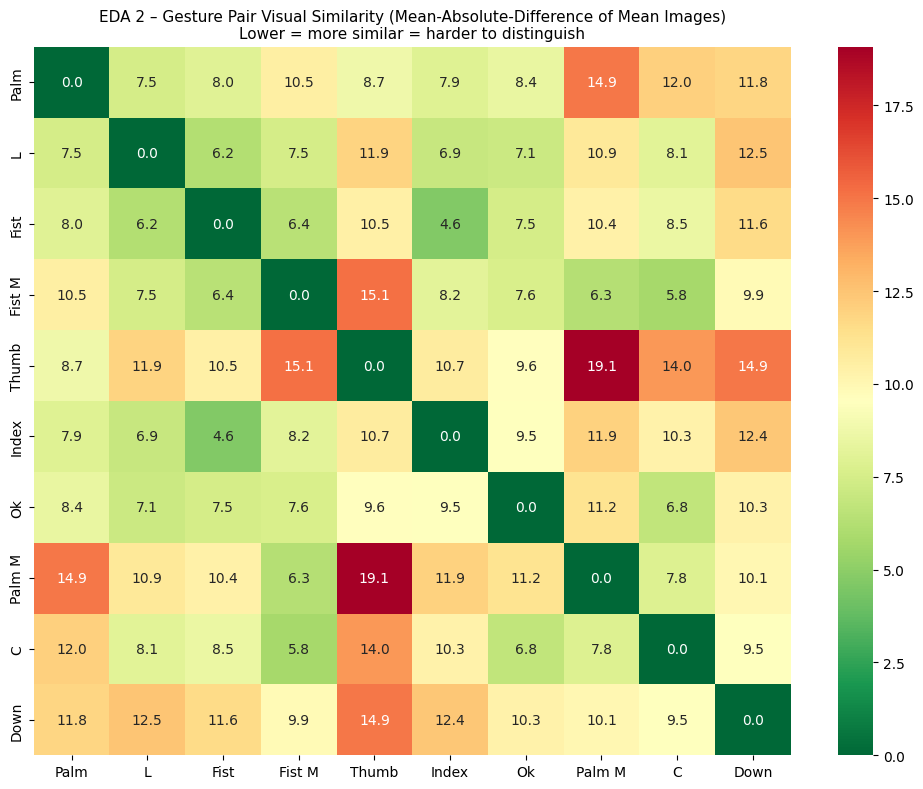

Most visually similar gesture pairs (MAD < 30):
  Palm ↔ L: MAD=7.5
  Palm ↔ Fist: MAD=8.0
  Palm ↔ Fist Moved: MAD=10.5
  Palm ↔ Thumb: MAD=8.7
  Palm ↔ Index: MAD=7.9
  Palm ↔ Ok: MAD=8.4
  Palm ↔ Palm Moved: MAD=14.9
  Palm ↔ C: MAD=12.0
  Palm ↔ Down: MAD=11.8
  L ↔ Fist: MAD=6.2
  L ↔ Fist Moved: MAD=7.5
  L ↔ Thumb: MAD=11.9
  L ↔ Index: MAD=6.9
  L ↔ Ok: MAD=7.1
  L ↔ Palm Moved: MAD=10.9
  L ↔ C: MAD=8.1
  L ↔ Down: MAD=12.5
  Fist ↔ Fist Moved: MAD=6.4
  Fist ↔ Thumb: MAD=10.5
  Fist ↔ Index: MAD=4.6
  Fist ↔ Ok: MAD=7.5
  Fist ↔ Palm Moved: MAD=10.4
  Fist ↔ C: MAD=8.5
  Fist ↔ Down: MAD=11.6
  Fist Moved ↔ Thumb: MAD=15.1
  Fist Moved ↔ Index: MAD=8.2
  Fist Moved ↔ Ok: MAD=7.6
  Fist Moved ↔ Palm Moved: MAD=6.3
  Fist Moved ↔ C: MAD=5.8
  Fist Moved ↔ Down: MAD=9.9
  Thumb ↔ Index: MAD=10.7
  Thumb ↔ Ok: MAD=9.6
  Thumb ↔ Palm Moved: MAD=19.1
  Thumb ↔ C: MAD=14.0
  Thumb ↔ Down: MAD=14.9
  Index ↔ Ok: MAD=9.5
  Index ↔ Palm Moved: MAD=11.9
  Index ↔ C: MAD=10.3
  Index ↔ D

In [ ]:

N = 50
mean_imgs = {}
for gid in range(10):
    paths = df[df['label']==gid]['filepath'].sample(N, random_state=0).tolist()
    imgs  = [cv2.resize(cv2.imread(p, cv2.IMREAD_GRAYSCALE),
                        (IMG_SIZE, IMG_SIZE)).astype(np.float32) for p in paths if cv2.imread(p) is not None]
    mean_imgs[gid] = np.stack(imgs).mean(axis=0)


sim_matrix = np.zeros((10, 10))
for i in range(10):
    for j in range(10):
        sim_matrix[i, j] = np.abs(mean_imgs[i] - mean_imgs[j]).mean()

labels_short = [GESTURE_NAMES[i][:6] for i in range(10)]
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sim_matrix, annot=True, fmt='.1f', cmap='RdYlGn_r',
            xticklabels=labels_short, yticklabels=labels_short, ax=ax)
ax.set_title('EDA 2 – Gesture Pair Visual Similarity (Mean-Absolute-Difference of Mean Images)\n'
             'Lower = more similar = harder to distinguish', fontsize=11)
plt.tight_layout(); plt.show()
print("Most visually similar gesture pairs (MAD < 30):")
for i in range(10):
    for j in range(i+1, 10):
        if sim_matrix[i,j] < 30:
            print(f"  {GESTURE_NAMES[i]} ↔ {GESTURE_NAMES[j]}: MAD={sim_matrix[i,j]:.1f}")


##  Foreground Coverage Ratio per Gesture Class


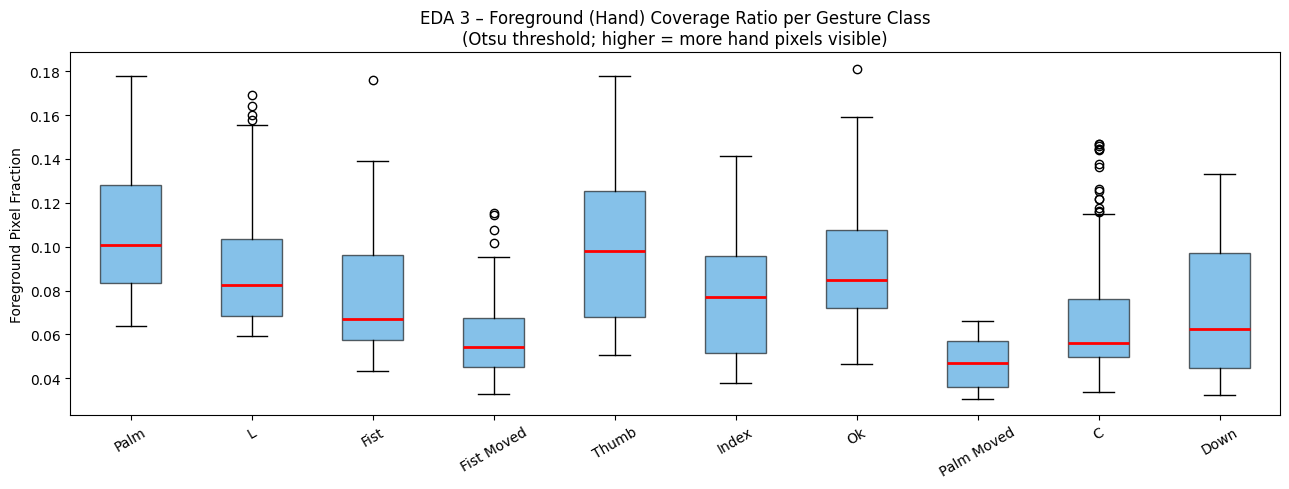

Palm          : mean=0.109  std=0.029
L             : mean=0.091  std=0.029
Fist          : mean=0.076  std=0.026
Fist Moved    : mean=0.059  std=0.019
Thumb         : mean=0.102  std=0.036
Index         : mean=0.077  std=0.024
Ok            : mean=0.092  std=0.029
Palm Moved    : mean=0.047  std=0.011
C             : mean=0.068  std=0.032
Down          : mean=0.072  std=0.030


In [ ]:

fg_ratios = {gid: [] for gid in range(10)}

for gid in range(10):
    paths = df[df['label']==gid]['filepath'].sample(n=100, random_state=3).tolist()
    for p in paths:
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is None: continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        _, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        fg_ratios[gid].append((thresh > 0).mean())

# Box-plot
fig, ax = plt.subplots(figsize=(13, 5))
data   = [fg_ratios[g] for g in range(10)]
labels = [GESTURE_NAMES[g] for g in range(10)]
bp = ax.boxplot(data, labels=labels, patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
ax.set_title('EDA 3 – Foreground (Hand) Coverage Ratio per Gesture Class\n'
             '(Otsu threshold; higher = more hand pixels visible)', fontsize=12)
ax.set_ylabel('Foreground Pixel Fraction'); ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

for gid in range(10):
    vals = fg_ratios[gid]
    print(f"{GESTURE_NAMES[gid]:<14}: mean={np.mean(vals):.3f}  std={np.std(vals):.3f}")


## Image Sharpness Distribution per Gesture Class


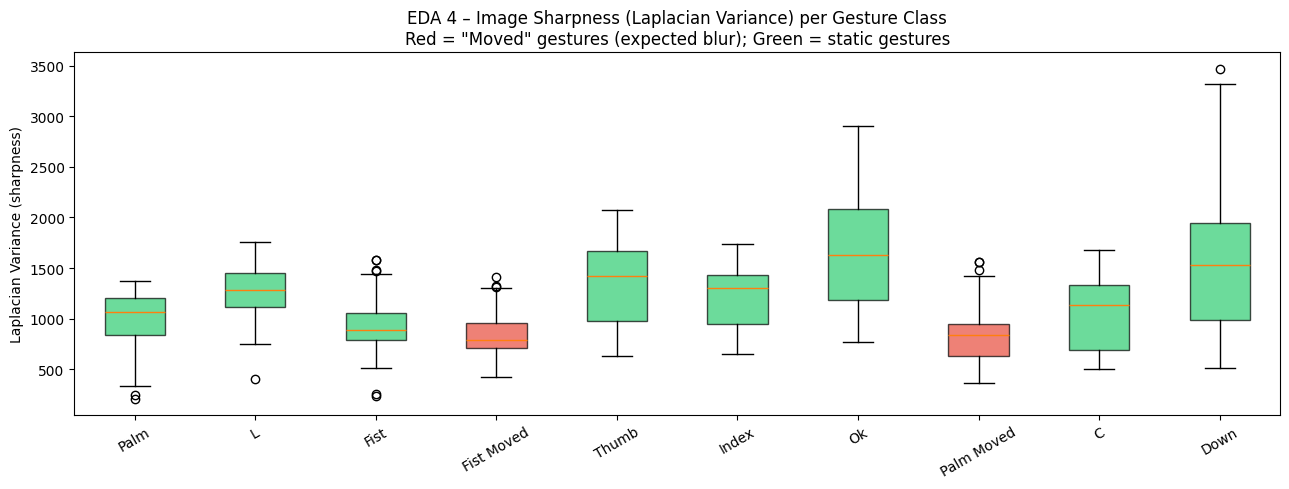

In [ ]:

sharpness = {gid: [] for gid in range(10)}

for gid in range(10):
    paths = df[df['label']==gid]['filepath'].sample(n=100, random_state=5).tolist()
    for p in paths:
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is None: continue
        img  = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        lap  = cv2.Laplacian(img.astype(np.float64), cv2.CV_64F)
        sharpness[gid].append(lap.var())

fig, ax = plt.subplots(figsize=(13, 5))
data   = [sharpness[g] for g in range(10)]
colors = ['#e74c3c' if 'moved' in GESTURE_NAMES[g].lower() else '#2ecc71' for g in range(10)]
bp = ax.boxplot(data, labels=[GESTURE_NAMES[g] for g in range(10)],
                patch_artist=True,
                boxprops=dict(alpha=0.7))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_title('EDA 4 – Image Sharpness (Laplacian Variance) per Gesture Class\n'
             'Red = "Moved" gestures (expected blur); Green = static gestures', fontsize=12)
ax.set_ylabel('Laplacian Variance (sharpness)'); ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()


##  Gesture Aspect-Ratio & Bounding-Box Width-to-Height Distribution


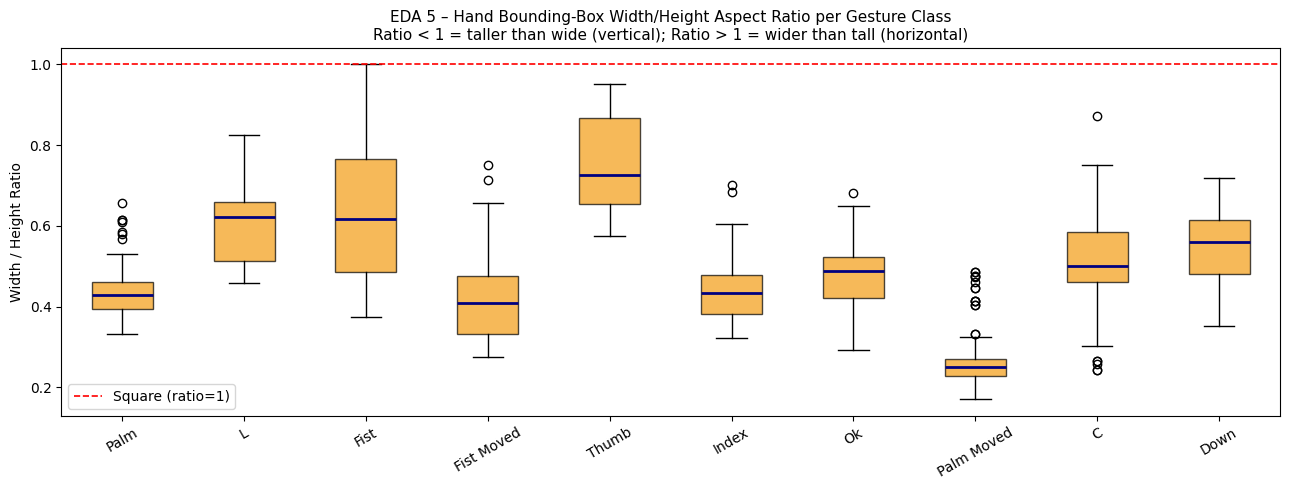

Palm          : median=0.429  orientation=vertical
L             : median=0.622  orientation=vertical
Fist          : median=0.617  orientation=vertical
Fist Moved    : median=0.410  orientation=vertical
Thumb         : median=0.727  orientation=vertical
Index         : median=0.433  orientation=vertical
Ok            : median=0.488  orientation=vertical
Palm Moved    : median=0.250  orientation=vertical
C             : median=0.500  orientation=vertical
Down          : median=0.561  orientation=vertical


In [ ]:

aspect_ratios = {gid: [] for gid in range(10)}

for gid in range(10):
    paths = df[df['label']==gid]['filepath'].sample(n=80, random_state=9).tolist()
    for p in paths:
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is None: continue
        img  = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        _, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        coords = cv2.findNonZero(thresh)
        if coords is None: continue
        x, y, w, h = cv2.boundingRect(coords)
        if h > 0:
            aspect_ratios[gid].append(w / h)

fig, ax = plt.subplots(figsize=(13, 5))
data   = [aspect_ratios[g] for g in range(10)]
bp = ax.boxplot(data, labels=[GESTURE_NAMES[g] for g in range(10)],
                patch_artist=True, boxprops=dict(facecolor='#f39c12', alpha=0.7),
                medianprops=dict(color='navy', linewidth=2))
ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1.2, label='Square (ratio=1)')
ax.set_title('EDA 5 – Hand Bounding-Box Width/Height Aspect Ratio per Gesture Class\n'
             'Ratio < 1 = taller than wide (vertical); Ratio > 1 = wider than tall (horizontal)', fontsize=11)
ax.set_ylabel('Width / Height Ratio'); ax.tick_params(axis='x', rotation=30); ax.legend()
plt.tight_layout(); plt.show()

for gid in range(10):
    vals = aspect_ratios[gid]
    print(f"{GESTURE_NAMES[gid]:<14}: median={np.median(vals):.3f}  "
          f"orientation={'horizontal' if np.median(vals)>=1 else 'vertical'}")


## Visualising Sample Images from the Dataset

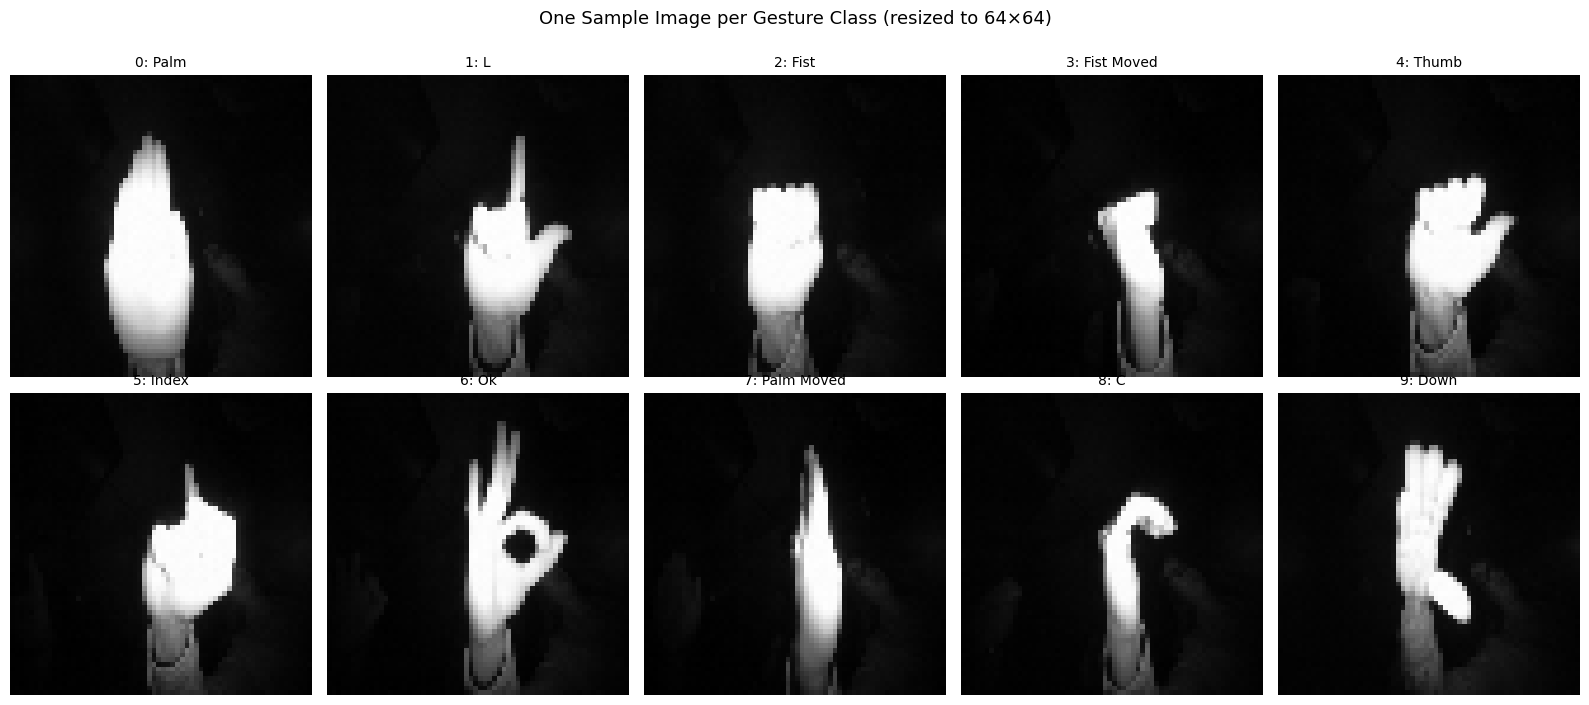

In [ ]:

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for gid, ax in enumerate(axes.ravel()):
    sample_path = df[df['label']==gid]['filepath'].iloc[0]
    img = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    ax.imshow(img, cmap='gray')
    ax.set_title(f'{gid}: {GESTURE_NAMES[gid]}', fontsize=10)
    ax.axis('off')
plt.suptitle('One Sample Image per Gesture Class (resized to 64×64)', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


# **Image Processing**



## Otsu Binary Thresholding (Hand Segmentation)



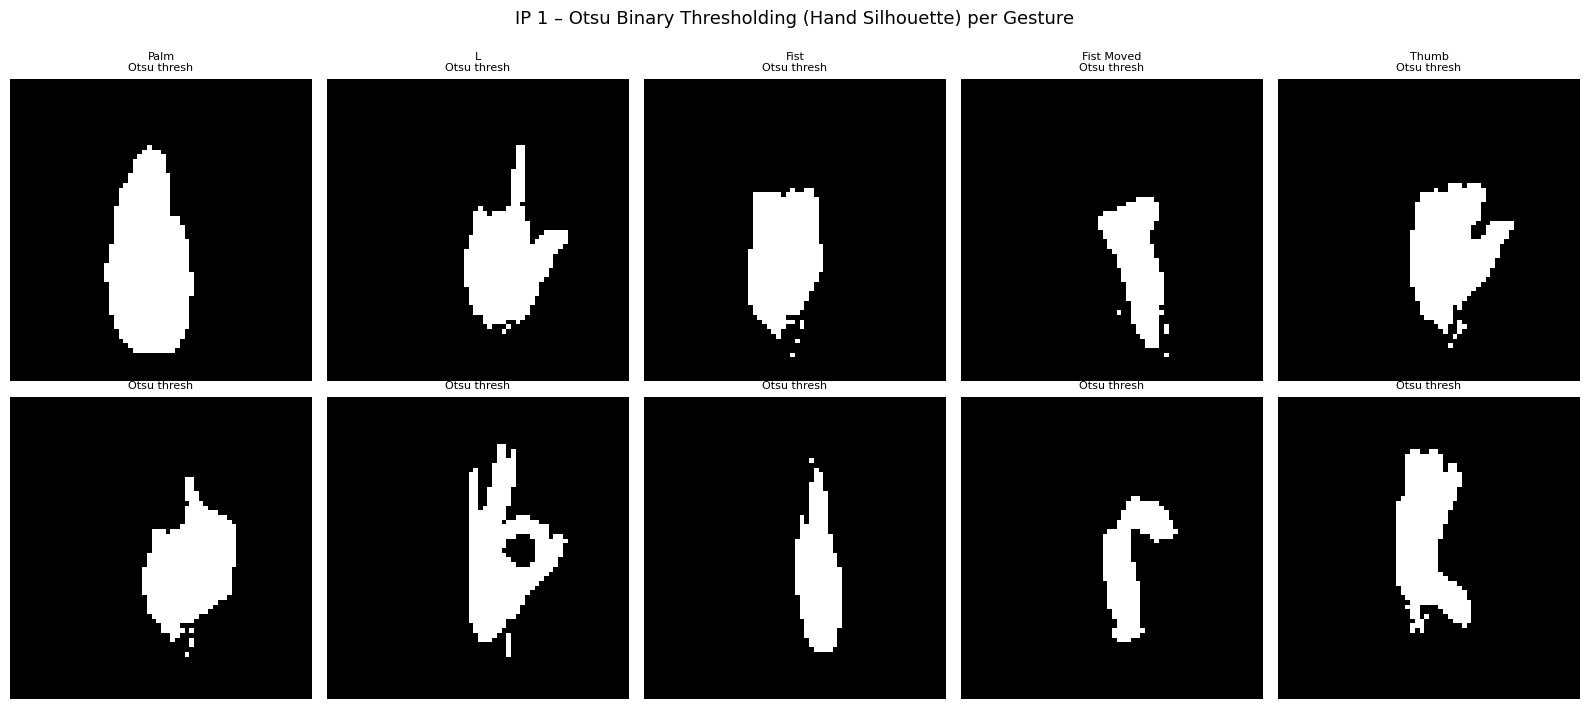

In [ ]:

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for gid, ax in enumerate(axes.ravel()):
    path = df[df['label']==gid]['filepath'].iloc[0]
    img  = cv2.resize(cv2.imread(path, cv2.IMREAD_GRAYSCALE), (IMG_SIZE, IMG_SIZE))
    _, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    ax.imshow(thresh, cmap='gray')
    ax.set_title(f'{GESTURE_NAMES[gid]}\nOtsu thresh', fontsize=8)
    ax.axis('off')
plt.suptitle('IP 1 – Otsu Binary Thresholding (Hand Silhouette) per Gesture', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


##  Contour Extraction & Convex Hull



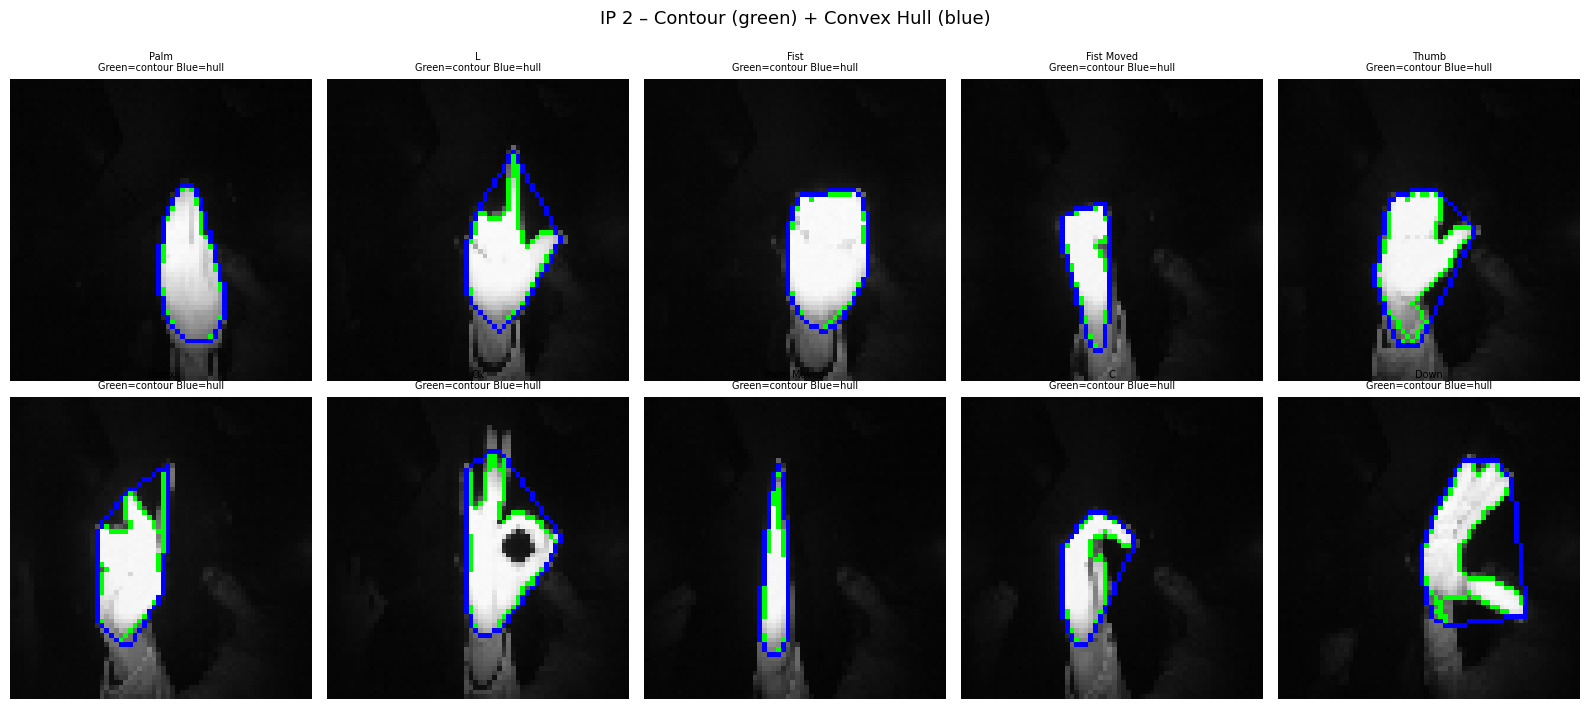

In [ ]:

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for gid, ax in enumerate(axes.ravel()):
    path = df[df['label']==gid]['filepath'].iloc[2]
    img  = cv2.resize(cv2.imread(path, cv2.IMREAD_GRAYSCALE), (IMG_SIZE, IMG_SIZE))
    _, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    canvas = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    if contours:
        cnt  = max(contours, key=cv2.contourArea)
        hull = cv2.convexHull(cnt)
        cv2.drawContours(canvas, [cnt],  -1, (0, 255, 0), 1)
        cv2.drawContours(canvas, [hull], -1, (255, 0, 0), 1)
    ax.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    ax.set_title(f'{GESTURE_NAMES[gid]}\nGreen=contour Blue=hull', fontsize=7)
    ax.axis('off')
plt.suptitle('IP 2 – Contour (green) + Convex Hull (blue)', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


##  Distance Transform (Finger Skeleton Proxy)



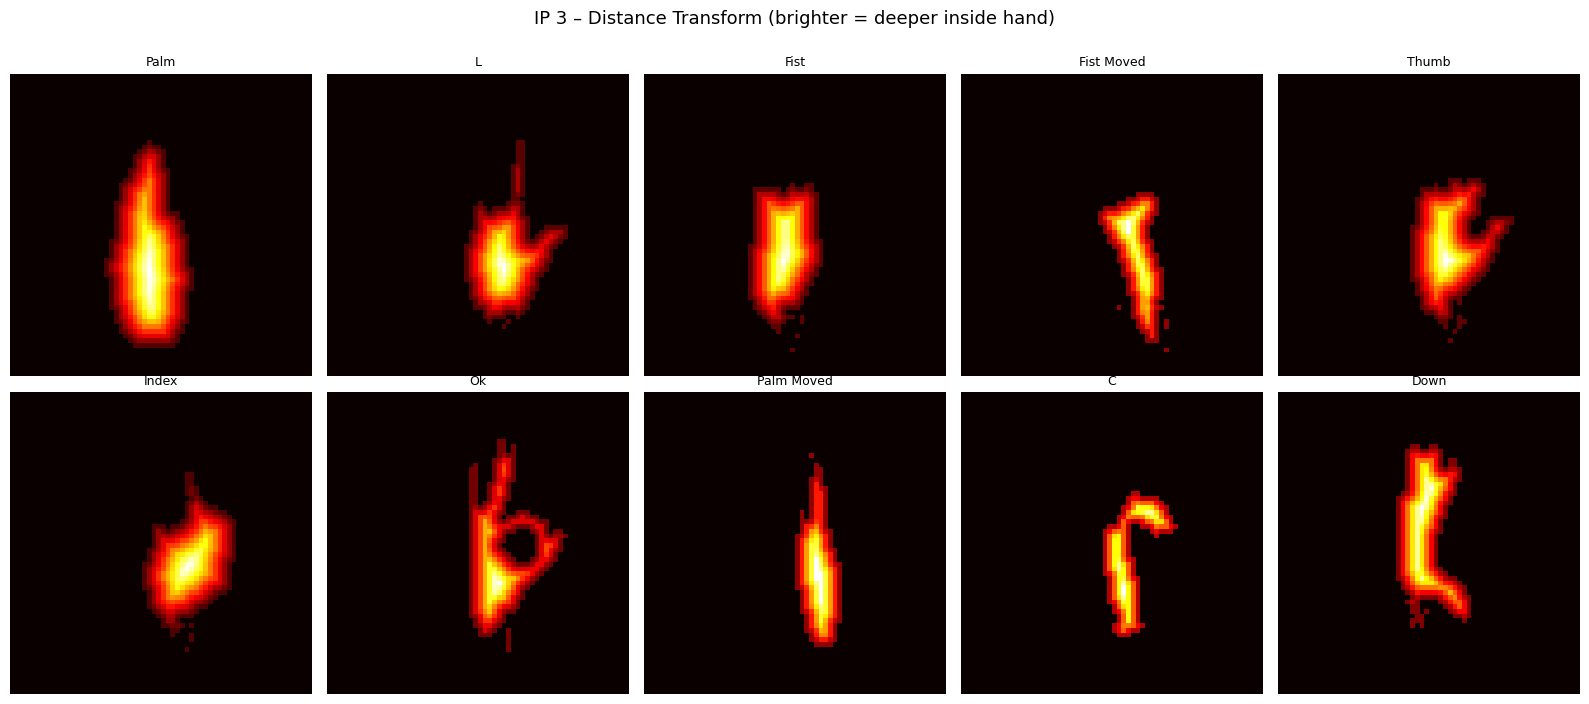

In [ ]:

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for gid, ax in enumerate(axes.ravel()):
    path = df[df['label']==gid]['filepath'].iloc[0]
    img  = cv2.resize(cv2.imread(path, cv2.IMREAD_GRAYSCALE), (IMG_SIZE, IMG_SIZE))
    _, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    dist = cv2.distanceTransform(thresh, cv2.DIST_L2, 5)
    dist_norm = cv2.normalize(dist, None, 0, 1.0, cv2.NORM_MINMAX)
    im = ax.imshow(dist_norm, cmap='hot')
    ax.set_title(f'{GESTURE_NAMES[gid]}', fontsize=9); ax.axis('off')
plt.suptitle('IP 3 – Distance Transform (brighter = deeper inside hand)', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


## Laplacian of Gaussian (LoG) Blob Detection


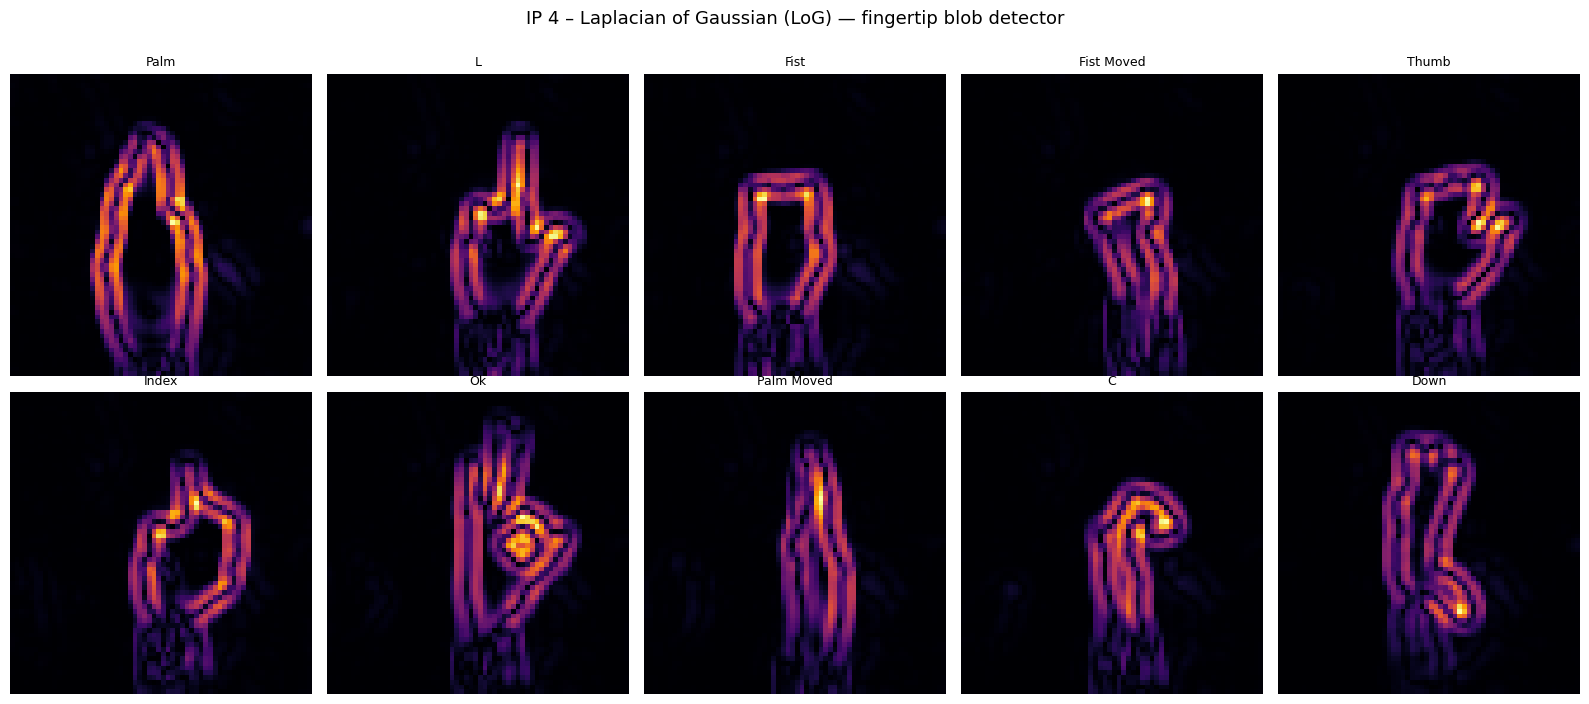

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for gid, ax in enumerate(axes.ravel()):
    path = df[df['label']==gid]['filepath'].iloc[0]
    img  = cv2.resize(cv2.imread(path, cv2.IMREAD_GRAYSCALE), (IMG_SIZE, IMG_SIZE)).astype(np.float32)
    blurred = cv2.GaussianBlur(img, (5, 5), 1.5)

    log     = cv2.Laplacian(blurred.astype(np.float64), cv2.CV_64F)
    log_abs = np.abs(log)
    log_norm = (log_abs / log_abs.max() * 255).astype(np.uint8)
    ax.imshow(log_norm, cmap='inferno'); ax.set_title(f'{GESTURE_NAMES[gid]}', fontsize=9); ax.axis('off')
plt.suptitle('IP 4 – Laplacian of Gaussian (LoG) — fingertip blob detector', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

##  Gabor Filter Bank (Texture / Orientation Analysis)


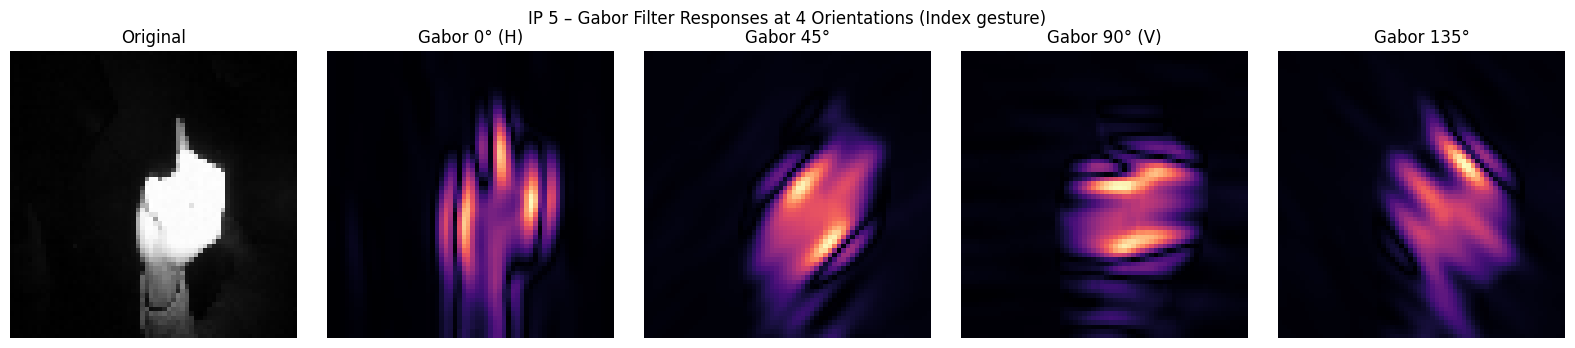

In [ ]:

def gabor_filter(img, theta):
    kern = cv2.getGaborKernel((15, 15), sigma=3.0, theta=theta,
                               lambd=8.0, gamma=0.5, psi=0)
    return cv2.filter2D(img.astype(np.float32), cv2.CV_32F, kern)

path     = df[df['label']==5]['filepath'].iloc[0]   # Index finger
img_orig = cv2.resize(cv2.imread(path, cv2.IMREAD_GRAYSCALE), (IMG_SIZE, IMG_SIZE))
thetas   = [0, np.pi/4, np.pi/2, 3*np.pi/4]
theta_labels = ['0° (H)', '45°', '90° (V)', '135°']

fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
axes[0].imshow(img_orig, cmap='gray'); axes[0].set_title('Original'); axes[0].axis('off')
for ax, theta, lbl in zip(axes[1:], thetas, theta_labels):
    resp = gabor_filter(img_orig, theta)
    ax.imshow(np.abs(resp), cmap='magma'); ax.set_title(f'Gabor {lbl}'); ax.axis('off')
plt.suptitle('IP 5 – Gabor Filter Responses at 4 Orientations (Index gesture)', fontsize=12)
plt.tight_layout(); plt.show()


##  HOG (Histogram of Oriented Gradients) Visualisation


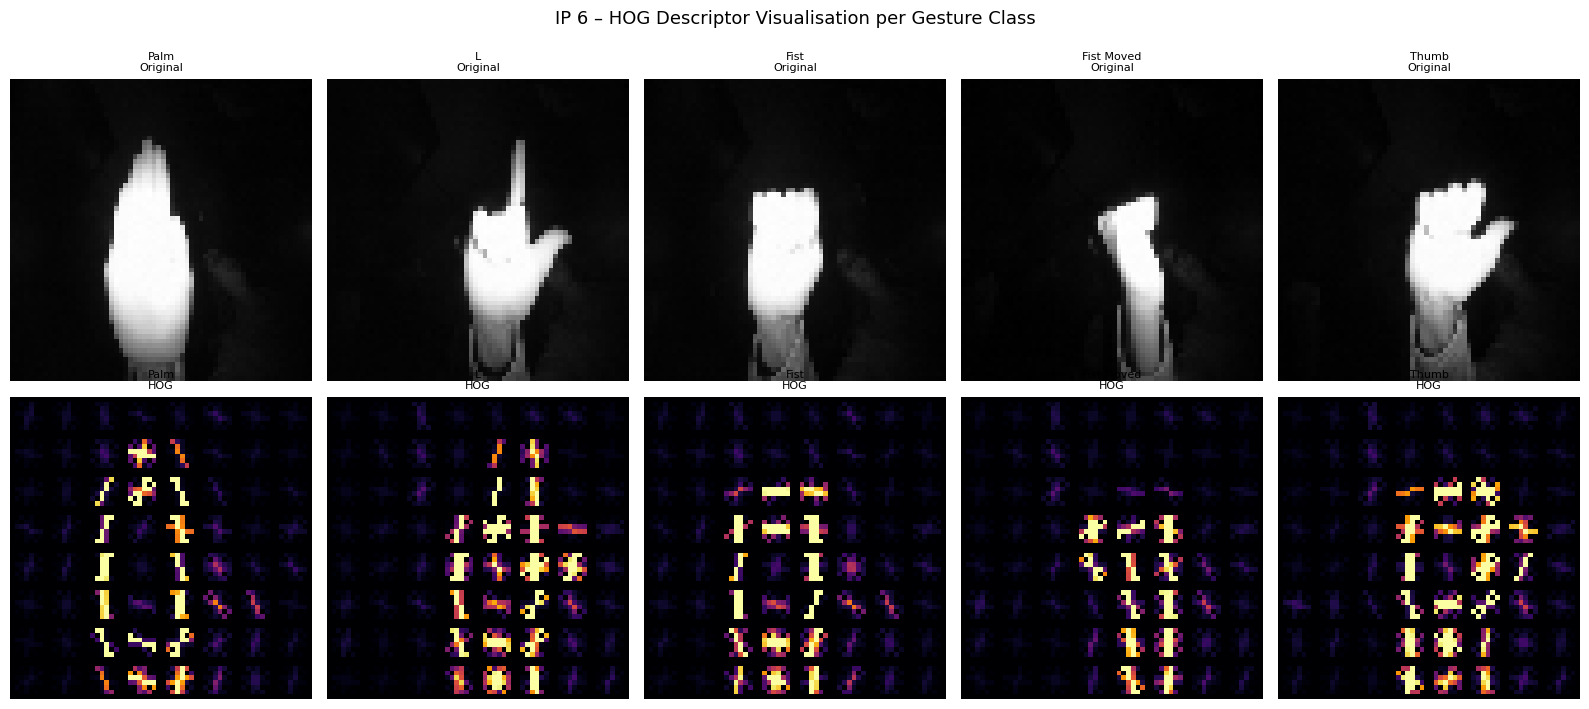

In [ ]:

from skimage.feature import hog
from skimage import exposure

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for gid, (ax_orig, ax_hog) in enumerate(zip(axes[0], axes[1])):
    path = df[df['label']==gid]['filepath'].iloc[0]
    img  = cv2.resize(cv2.imread(path, cv2.IMREAD_GRAYSCALE), (IMG_SIZE, IMG_SIZE))
    fd, hog_img = hog(img, orientations=8, pixels_per_cell=(8, 8),
                      cells_per_block=(2, 2), visualize=True)
    hog_img_rs = exposure.rescale_intensity(hog_img, in_range=(0, 10))
    ax_orig.imshow(img,       cmap='gray');   ax_orig.set_title(f'{GESTURE_NAMES[gid]}\nOriginal',  fontsize=8); ax_orig.axis('off')
    ax_hog.imshow(hog_img_rs, cmap='inferno'); ax_hog.set_title(f'{GESTURE_NAMES[gid]}\nHOG',       fontsize=8); ax_hog.axis('off')
plt.suptitle('IP 6 – HOG Descriptor Visualisation per Gesture Class', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


##  Skeleton / Thinning (Medial Axis)



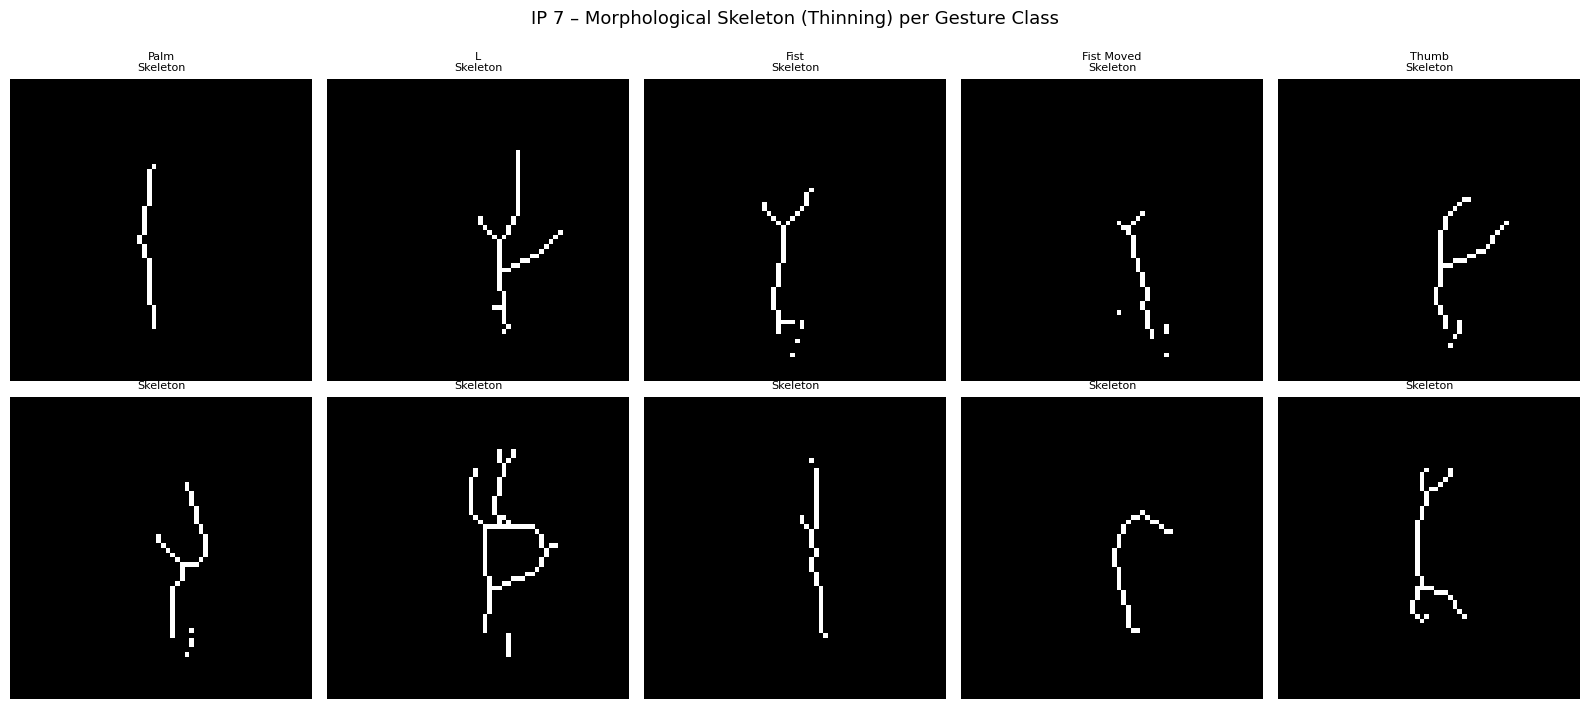

In [ ]:

from skimage.morphology import skeletonize

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for gid, ax in enumerate(axes.ravel()):
    path  = df[df['label']==gid]['filepath'].iloc[0]
    img   = cv2.resize(cv2.imread(path, cv2.IMREAD_GRAYSCALE), (IMG_SIZE, IMG_SIZE))
    _, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    skel  = skeletonize(thresh > 0).astype(np.uint8) * 255
    ax.imshow(skel, cmap='gray')
    ax.set_title(f'{GESTURE_NAMES[gid]}\nSkeleton', fontsize=8); ax.axis('off')
plt.suptitle('IP 7 – Morphological Skeleton (Thinning) per Gesture Class', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


##  LBP (Local Binary Pattern) Texture Map


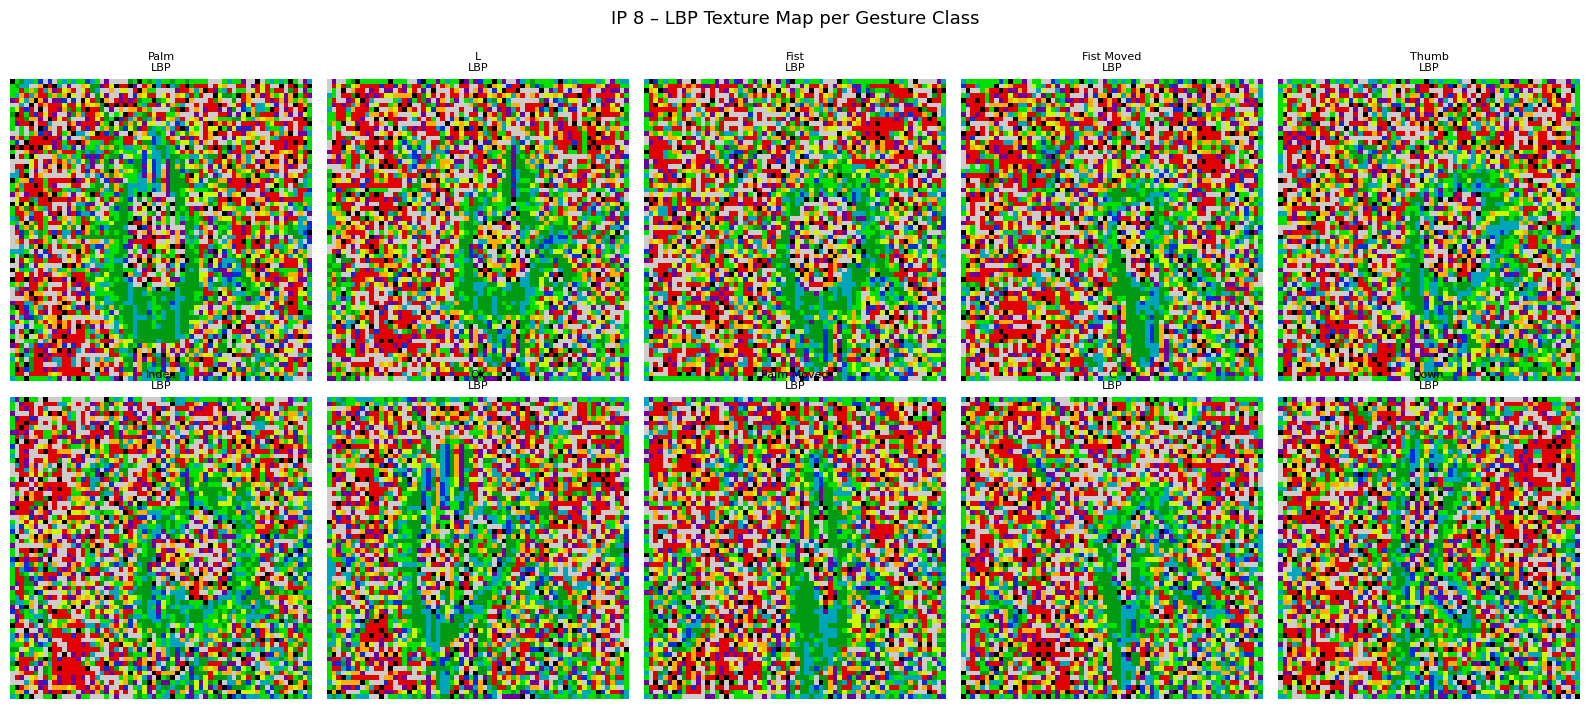

In [ ]:

from skimage.feature import local_binary_pattern

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for gid, ax in enumerate(axes.ravel()):
    path = df[df['label']==gid]['filepath'].iloc[1]
    img  = cv2.resize(cv2.imread(path, cv2.IMREAD_GRAYSCALE), (IMG_SIZE, IMG_SIZE))
    lbp  = local_binary_pattern(img, P=8, R=1, method='uniform')
    ax.imshow(lbp, cmap='nipy_spectral')
    ax.set_title(f'{GESTURE_NAMES[gid]}\nLBP', fontsize=8); ax.axis('off')
plt.suptitle('IP 8 – LBP Texture Map per Gesture Class', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


## Finger Count Estimation via Convexity Defects


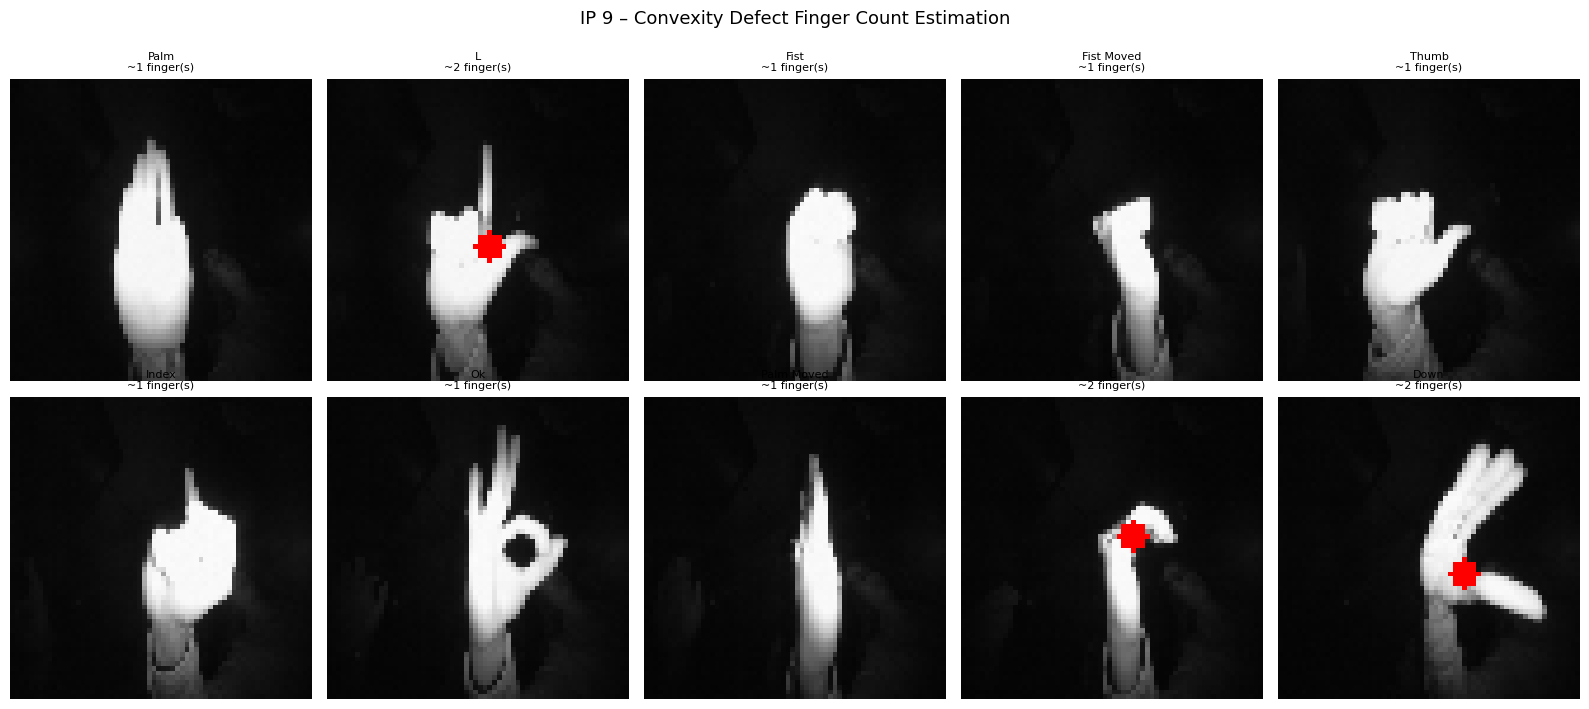

In [ ]:

def estimate_fingers(img_gray):
    _, thresh = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours: return 0, img_gray
    cnt   = max(contours, key=cv2.contourArea)
    hull  = cv2.convexHull(cnt, returnPoints=False)
    if len(hull) < 4: return 0, img_gray
    defects = cv2.convexityDefects(cnt, hull)
    if defects is None: return 0, img_gray
    count   = 0
    canvas  = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)
    for i in range(defects.shape[0]):
        s, e, f, d = defects[i, 0]
        start = tuple(cnt[s][0]); end = tuple(cnt[e][0]); far = tuple(cnt[f][0])
        a = np.linalg.norm(np.array(end) - np.array(start))
        b = np.linalg.norm(np.array(far) - np.array(start))
        c = np.linalg.norm(np.array(end) - np.array(far))
        angle = np.arccos(max(-1, min(1, (b**2 + c**2 - a**2) / (2*b*c + 1e-6))))
        if angle < np.pi/2 and d > 2000:
            count += 1
            cv2.circle(canvas, far, 3, (0, 0, 255), -1)
    return count + 1, canvas

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for gid, ax in enumerate(axes.ravel()):
    path = df[df['label']==gid]['filepath'].iloc[3]
    img  = cv2.resize(cv2.imread(path, cv2.IMREAD_GRAYSCALE), (IMG_SIZE, IMG_SIZE))
    n_fingers, canvas = estimate_fingers(img)
    ax.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    ax.set_title(f'{GESTURE_NAMES[gid]}\n~{n_fingers} finger(s)', fontsize=8); ax.axis('off')
plt.suptitle('IP 9 – Convexity Defect Finger Count Estimation', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


##  Frequency Domain Analysis (2D FFT Magnitude Spectrum)



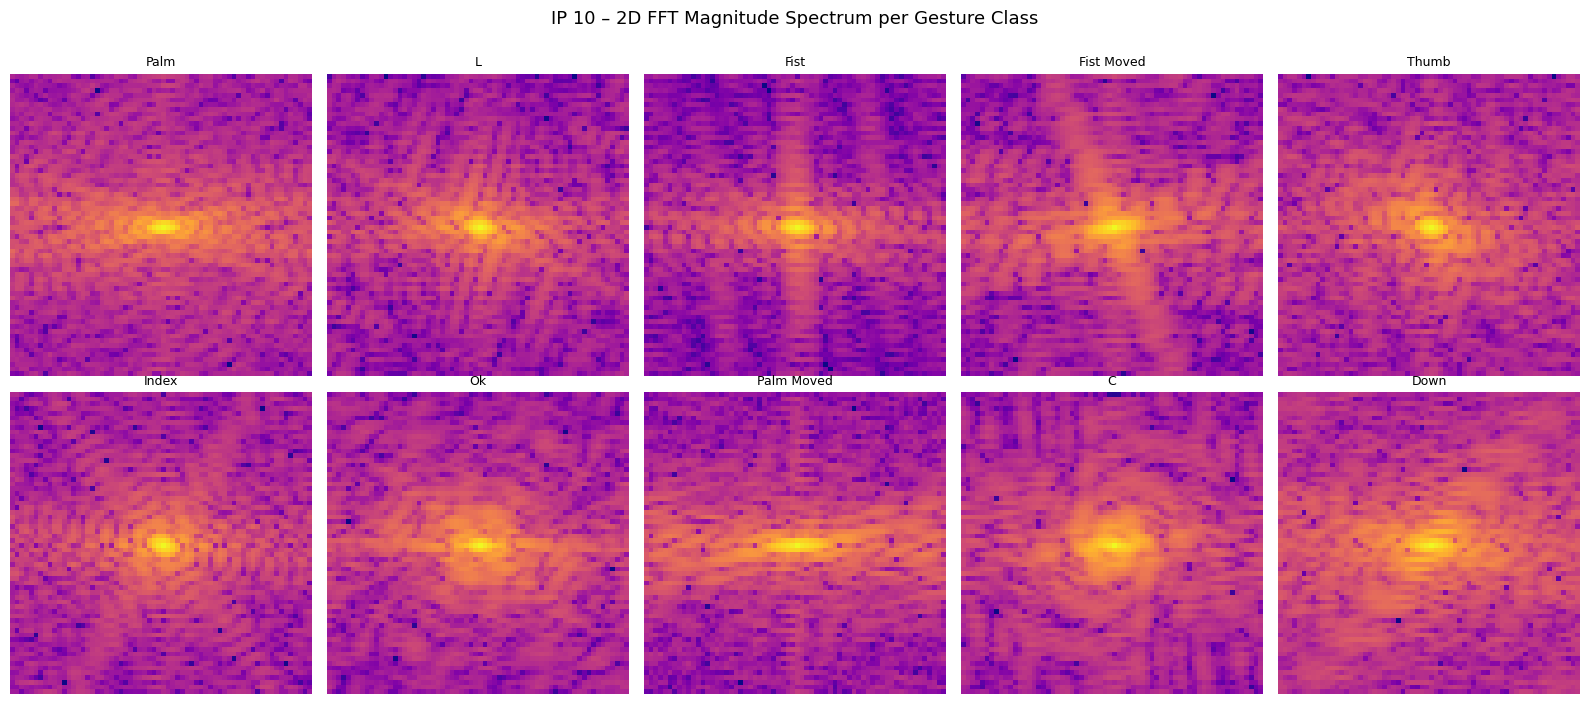

In [ ]:

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for gid, ax in enumerate(axes.ravel()):
    path = df[df['label']==gid]['filepath'].iloc[0]
    img  = cv2.resize(cv2.imread(path, cv2.IMREAD_GRAYSCALE), (IMG_SIZE, IMG_SIZE)).astype(np.float32)
    f    = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    mag  = 20 * np.log1p(np.abs(fshift))
    ax.imshow(mag, cmap='plasma'); ax.set_title(f'{GESTURE_NAMES[gid]}', fontsize=9); ax.axis('off')
plt.suptitle('IP 10 – 2D FFT Magnitude Spectrum per Gesture Class', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


# **Data Preprocessing**


In [ ]:

print("Loading images... (this may take ~1-2 min)")
X_all, y_all = [], []

for _, row in df.iterrows():
    img = cv2.imread(row['filepath'], cv2.IMREAD_GRAYSCALE)
    if img is not None:
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        X_all.append(img)
        y_all.append(row['label'])

X_all = np.array(X_all, dtype='float32')
y_all = np.array(y_all)
print(f"X_all shape: {X_all.shape}  |  y_all shape: {y_all.shape}")


Loading images... (this may take ~1-2 min)
X_all shape: (20000, 64, 64)  |  y_all shape: (20000,)


In [ ]:

from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X_all, y_all, test_size=0.10, random_state=42, stratify=y_all)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1111, random_state=42, stratify=y_temp)

print(f"Train : {X_train.shape}  |  Val : {X_val.shape}  |  Test : {X_test.shape}")


Train : (16000, 64, 64)  |  Val : (2000, 64, 64)  |  Test : (2000, 64, 64)


**Reshaping to (N, 64, 64, 1) and normalising pixels to [0, 1]:**

In [ ]:

X_train = X_train.reshape(X_train.shape[0], IMG_SIZE, IMG_SIZE, 1) / 255.0
X_val   = X_val.reshape(X_val.shape[0],     IMG_SIZE, IMG_SIZE, 1) / 255.0
X_test  = X_test.reshape(X_test.shape[0],   IMG_SIZE, IMG_SIZE, 1) / 255.0

y_train = to_categorical(y_train, num_classes=10)
y_val   = to_categorical(y_val,   num_classes=10)
y_test  = to_categorical(y_test,  num_classes=10)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape,   "y_val  :", y_val.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)
print("Pixel range → min:", X_train.min(), " max:", X_train.max())


X_train: (16000, 64, 64, 1) y_train: (16000, 10)
X_val  : (2000, 64, 64, 1) y_val  : (2000, 10)
X_test : (2000, 64, 64, 1) y_test : (2000, 10)
Pixel range → min: 0.003921569  max: 0.99215686


##  Per-Channel Pixel Mean & Std (Z-Score Normalisation Preview)


Dataset-level pixel statistics (after /255):
  Mean : 0.09750
  Std  : 0.20759

For Z-score normalisation you would apply:
  X_norm = (X - 0.09750) / 0.20759


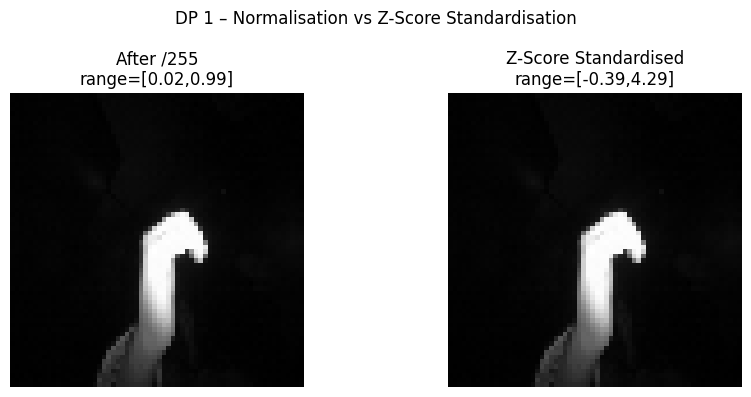

In [ ]:

flat = X_train.ravel()
ds_mean = flat.mean(); ds_std = flat.std()
print(f"Dataset-level pixel statistics (after /255):")
print(f"  Mean : {ds_mean:.5f}")
print(f"  Std  : {ds_std:.5f}")
print(f"\nFor Z-score normalisation you would apply:")
print(f"  X_norm = (X - {ds_mean:.5f}) / {ds_std:.5f}")

sample = X_train[0].squeeze()
zscore = (sample - ds_mean) / (ds_std + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(sample, cmap='gray'); axes[0].set_title(f'After /255\nrange=[{sample.min():.2f},{sample.max():.2f}]')
axes[1].imshow(zscore, cmap='gray'); axes[1].set_title(f'Z-Score Standardised\nrange=[{zscore.min():.2f},{zscore.max():.2f}]')
for ax in axes: ax.axis('off')
plt.suptitle('DP 1 – Normalisation vs Z-Score Standardisation', fontsize=12)
plt.tight_layout(); plt.show()


##  Subject-Stratified Split Verification


Split sizes:
  Train: 16000 samples | min class=1600 max class=1600 (balance ratio=1.000)
  Val  :  2000 samples | min class= 200 max class= 200 (balance ratio=1.000)
  Test :  2000 samples | min class= 200 max class= 200 (balance ratio=1.000)


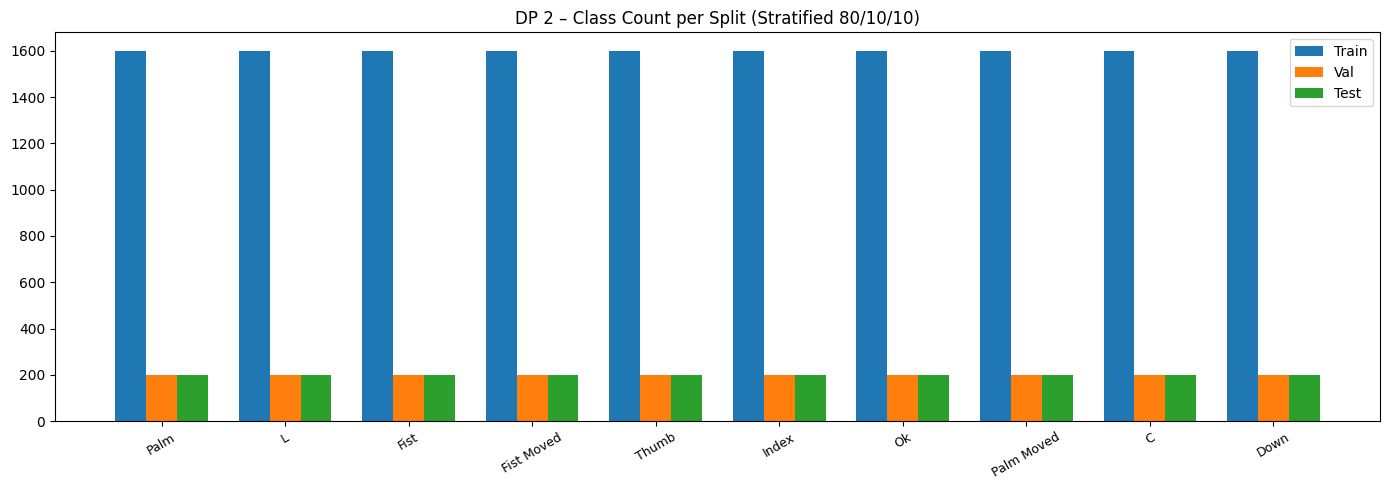

In [ ]:

df_reset   = df.reset_index(drop=True)
y_all_raw  = np.array([r for r in df_reset['label']])


all_paths = df_reset['filepath'].tolist()


def get_subjects_from_X_paths(X_arr, df_ref):

    y_idx = np.argmax(X_arr if X_arr.ndim == 2 else
                      np.zeros((len(X_arr), 10)), axis=1) if X_arr.ndim==2 else None
    return None

print("Split sizes:")
for name, X, y in [('Train', X_train, y_train), ('Val', X_val, y_val), ('Test', X_test, y_test)]:
    y_idx   = np.argmax(y, axis=1)
    counts  = {GESTURE_NAMES[g]: (y_idx==g).sum() for g in range(10)}
    total   = len(y_idx)
    cv_vals = list(counts.values())
    print(f"  {name:5s}: {total:5d} samples | "
          f"min class={min(cv_vals):4d} max class={max(cv_vals):4d} "
          f"(balance ratio={min(cv_vals)/max(cv_vals):.3f})")


fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(10); width = 0.25
for idx, (name, y) in enumerate([('Train',y_train),('Val',y_val),('Test',y_test)]):
    y_idx  = np.argmax(y, axis=1)
    counts = [(y_idx==g).sum() for g in range(10)]
    ax.bar(x+idx*width, counts, width, label=name)
ax.set_xticks(x+width)
ax.set_xticklabels([GESTURE_NAMES[g] for g in range(10)], rotation=30, fontsize=9)
ax.set_title('DP 2 – Class Count per Split (Stratified 80/10/10)', fontsize=12)
ax.legend(); plt.tight_layout(); plt.show()


## Foreground Coverage After Normalisation


Foreground fraction (normalised X_train, first 200 images):
  Mean : 0.0812  (8.1% of pixels are hand)
  Std  : 0.0325
  Min  : 0.0281   Max: 0.1780


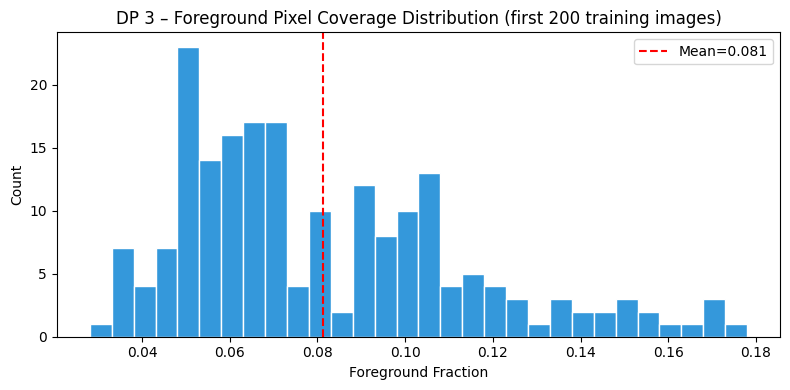

In [ ]:

sample_imgs = X_train[:200].squeeze()

fg_fractions = []
for img in sample_imgs:
    img_u8 = (img * 255).astype(np.uint8)
    _, thresh = cv2.threshold(img_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    fg_fractions.append((thresh > 0).mean())

fg_arr = np.array(fg_fractions)
print(f"Foreground fraction (normalised X_train, first 200 images):")
print(f"  Mean : {fg_arr.mean():.4f}  ({fg_arr.mean()*100:.1f}% of pixels are hand)")
print(f"  Std  : {fg_arr.std():.4f}")
print(f"  Min  : {fg_arr.min():.4f}   Max: {fg_arr.max():.4f}")

plt.figure(figsize=(8, 4))
plt.hist(fg_arr, bins=30, color='#3498db', edgecolor='white')
plt.axvline(fg_arr.mean(), color='red', linestyle='--', label=f'Mean={fg_arr.mean():.3f}')
plt.title('DP 3 – Foreground Pixel Coverage Distribution (first 200 training images)')
plt.xlabel('Foreground Fraction'); plt.ylabel('Count'); plt.legend()
plt.tight_layout(); plt.show()


##  HOG Feature Separability (t-SNE on HOG Descriptors)



HOG feature vector length: 1568
Running t-SNE (this takes ~30 sec)…


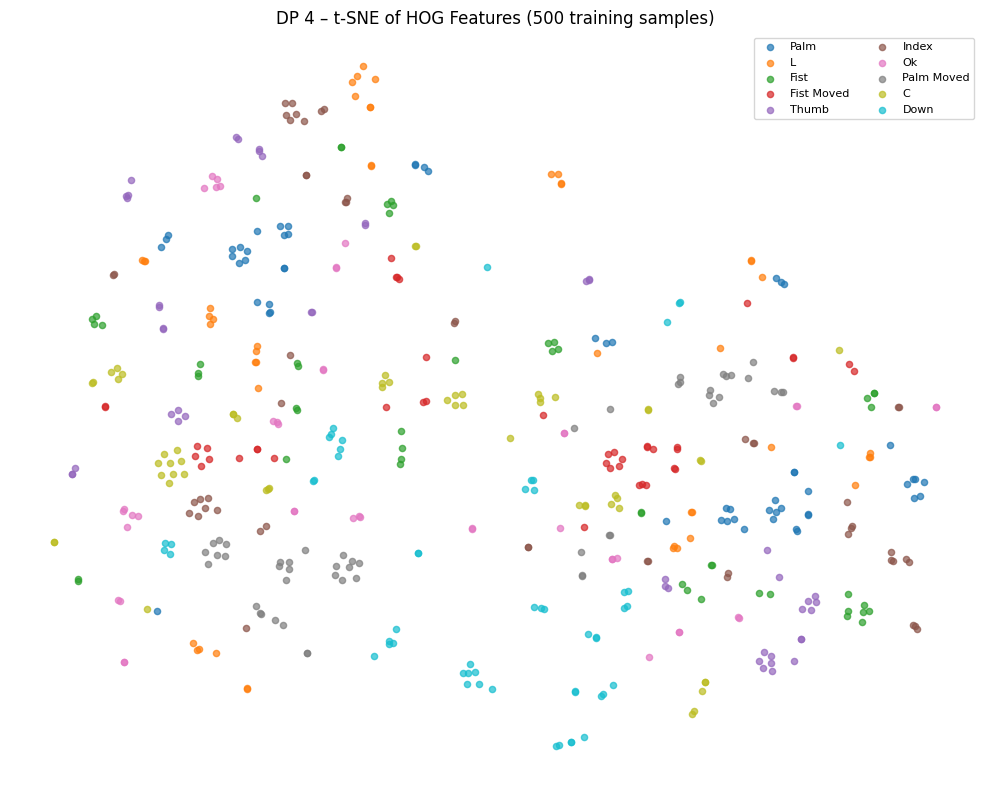

In [ ]:

from skimage.feature import hog
from sklearn.manifold import TSNE

N_SAMPLE  = 500
rng       = np.random.RandomState(42)
idx_sample = rng.choice(len(X_train), size=N_SAMPLE, replace=False)

X_sample   = X_train[idx_sample].squeeze()   # (500, 64, 64)
y_sample   = np.argmax(y_train[idx_sample], axis=1)

hog_feats = []
for img in X_sample:
    img_u8 = (img * 255).astype(np.uint8)
    fd = hog(img_u8, orientations=8, pixels_per_cell=(8,8),
             cells_per_block=(2,2), visualize=False)
    hog_feats.append(fd)
hog_feats = np.array(hog_feats)

print(f"HOG feature vector length: {hog_feats.shape[1]}")
print("Running t-SNE (this takes ~30 sec)…")
tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_iter=800)
emb  = tsne.fit_transform(hog_feats)

colors10 = plt.cm.tab10(np.linspace(0,1,10))
fig, ax  = plt.subplots(figsize=(10, 8))
for gid in range(10):
    mask = y_sample == gid
    ax.scatter(emb[mask, 0], emb[mask, 1], s=20, alpha=0.7,
               color=colors10[gid], label=GESTURE_NAMES[gid])
ax.set_title('DP 4 – t-SNE of HOG Features (500 training samples)', fontsize=12)
ax.legend(fontsize=8, ncol=2); ax.axis('off')
plt.tight_layout(); plt.show()


##  Pixel Variance Map per Gesture Class



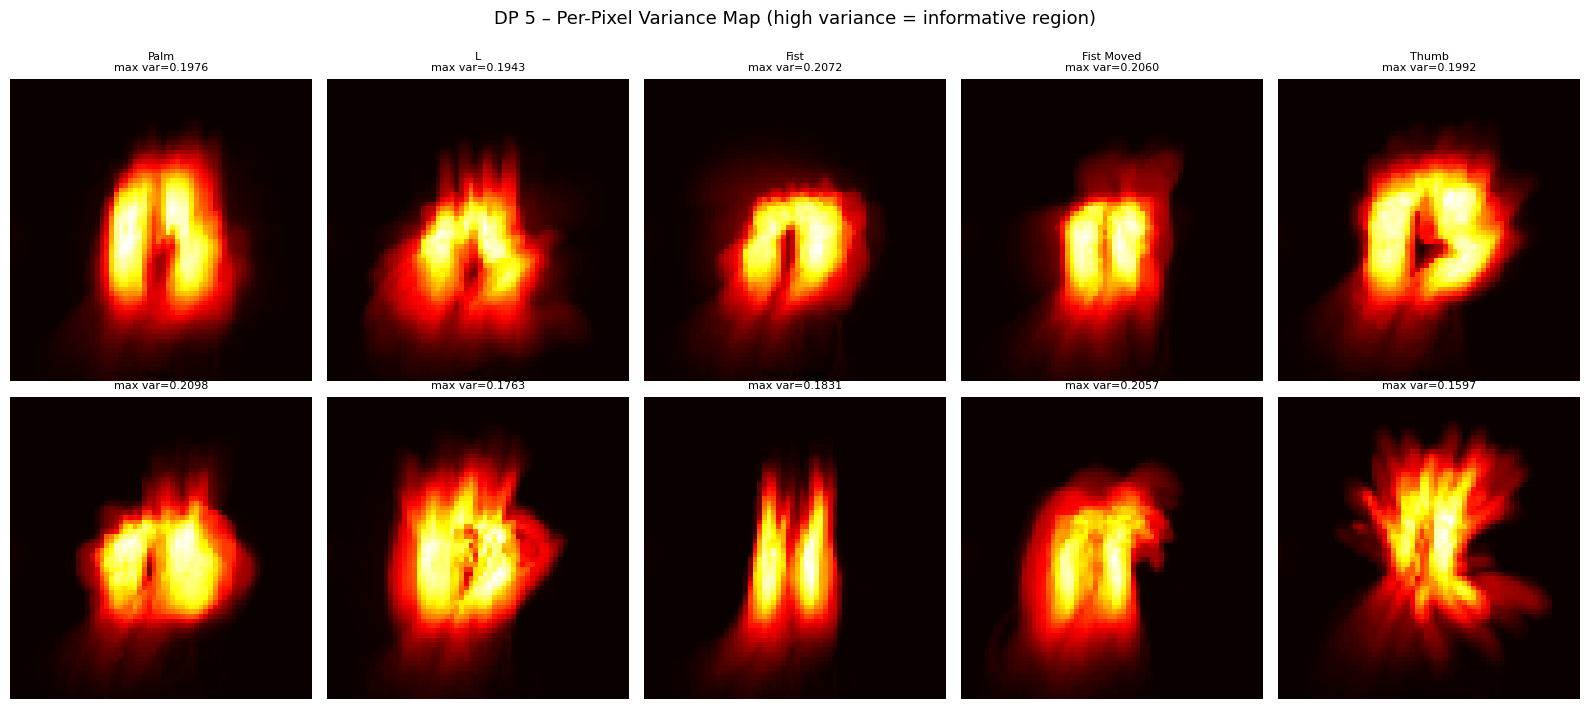

In [ ]:

y_train_idx = np.argmax(y_train, axis=1)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for gid, ax in enumerate(axes.ravel()):
    class_imgs = X_train[y_train_idx == gid].squeeze()  # (N, 64, 64)
    var_map    = class_imgs.var(axis=0)
    im = ax.imshow(var_map, cmap='hot')
    ax.set_title(f'{GESTURE_NAMES[gid]}\nmax var={var_map.max():.4f}', fontsize=8)
    ax.axis('off')

plt.suptitle('DP 5 – Per-Pixel Variance Map (high variance = informative region)', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


# Defining Base Model Architecture – Multi-Scale CNN



In [ ]:

from tensorflow.keras.layers import Concatenate

def multi_scale_block(x, filters):
    """Parallel 1×1 + 3×3 + 5×5 convolution branches, then concatenate"""
    b1 = Conv2D(filters//3, (1,1), padding='same', use_bias=False)(x)
    b1 = BatchNormalization()(b1); b1 = Activation('relu')(b1)

    b3 = Conv2D(filters//3, (3,3), padding='same', use_bias=False)(x)
    b3 = BatchNormalization()(b3); b3 = Activation('relu')(b3)

    b5 = Conv2D(filters//3, (5,5), padding='same', use_bias=False)(x)
    b5 = BatchNormalization()(b5); b5 = Activation('relu')(b5)

    return Concatenate()([b1, b3, b5])

def cnn_model():
    inp = Input(shape=(IMG_SIZE, IMG_SIZE, 1))

    x = multi_scale_block(inp, 48)
    x = MaxPooling2D((2, 2))(x); x = Dropout(0.25)(x)

    x = multi_scale_block(x, 96)
    x = MaxPooling2D((2, 2))(x); x = Dropout(0.25)(x)

    x = multi_scale_block(x, 192)
    x = MaxPooling2D((2, 2))(x); x = Dropout(0.25)(x)

    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x); x = Dropout(0.5)(x)
    out = Dense(10, activation='softmax')(x)
    return Model(inp, out, name='MultiScale_CNN')

model = cnn_model()
model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "MultiScale_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │         16 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │        144 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │        400 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │         64 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ activation[0][0], │
│ (Concatenate)       │ 48)               │            │ activation_1[0][… │
│                     │                   │            │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ concatenate[0][0] │
│ (MaxPooling2D)      │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32, 32,    │          0 │ max_pooling2d[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │      1,536 │ dropout[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     13,824 │ dropout[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │     38,400 │ dropout[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 322,682 (1.23 MB)

 Trainable params: 322,010 (1.23 MB)

 Non-trainable params: 672 (2.62 KB)

In [ ]:

checkpointer = [
    EarlyStopping(monitor='val_accuracy', verbose=1,
                  restore_best_weights=True, mode='max', patience=10),
    ModelCheckpoint('best_model.h5', monitor='val_accuracy', verbose=1,
                    save_best_only=True, mode='max')
]

history = model.fit(
    X_train, y_train,
    batch_size=64,
    epochs=50,
    callbacks=checkpointer,
    validation_data=(X_val, y_val)
)


Epoch 1/50
248/250 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3812 - loss: 1.7316
Epoch 1: val_accuracy improved from None to 0.11300, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.6134 - loss: 1.1444 - val_accuracy: 0.1130 - val_loss: 4.9812
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9437 - loss: 0.2120
Epoch 2: val_accuracy improved from 0.11300 to 0.47300, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9625 - loss: 0.1534 - val_accuracy: 0.4730 - val_loss: 1.8331
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9886 - loss: 0.0563
Epoch 3: val_accuracy improved from 0.47300 to 0.97900, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9893 - loss: 0.0516 - val_accuracy: 0.9790 - val_loss: 0.0835
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9938 - loss: 0.0274
Epoch 4: val_accuracy improved from 0.97900 to 0.99950, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9945 - loss: 0.0266 - val_accuracy: 0.9995 - val_loss: 0.0089
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9963 - loss: 0.0215
Epoch 5: val_accuracy did not improve from 0.99950
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9963 - loss: 0.0186 - val_accuracy: 0.9990 - val_loss: 0.0062
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9963 - loss: 0.0190
Epoch 6: val_accuracy did not improve from 0.99950
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9953 - loss: 0.0205 - val_accuracy: 0.9995 - val_loss: 0.0027
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9954 - loss: 0.0172
Epoch 7: val_accuracy improved from 0.99950 to 1.00000, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9972 - loss: 0.0138 - val_accuracy: 1.0000 - val_loss: 7.0049e-04
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9971 - loss: 0.0109
Epoch 8: val_accuracy did not improve from 1.00000
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9971 - loss: 0.0114 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 9/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9957 - loss: 0.0151
Epoch 9: val_accuracy did not improve from 1.00000
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9966 - loss: 0.0126 - val_accuracy: 0.9990 - val_loss: 0.0019
Epoch 10/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9983 - loss: 0.0072
Epoch 10: val_accuracy did not improve from 1.00000
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9981 - loss: 0.0077 - val_accuracy: 0.9990 - val_loss: 0.0042
Epoch 11/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - acc

# Model Evaluation


### **Loss / Accuracy training curves**


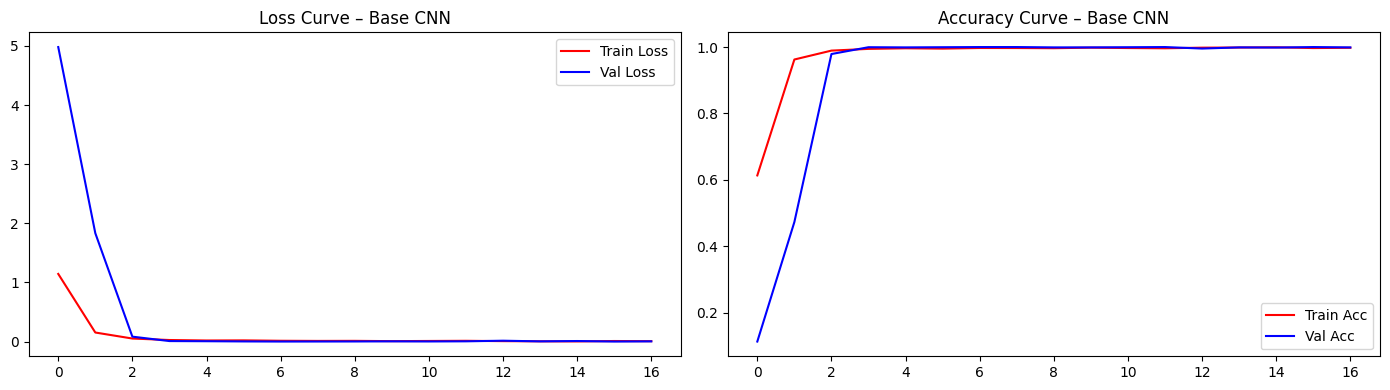

In [ ]:

def loss_plot(hist, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(hist.history['loss'],     'r', label='Train Loss')
    axes[0].plot(hist.history['val_loss'], 'b', label='Val Loss')
    axes[0].set_title(f'Loss Curve {title}'); axes[0].legend()

    axes[1].plot(hist.history['accuracy'],     'r', label='Train Acc')
    axes[1].plot(hist.history['val_accuracy'], 'b', label='Val Acc')
    axes[1].set_title(f'Accuracy Curve {title}'); axes[1].legend()
    plt.tight_layout(); plt.show()

loss_plot(history, '– Base CNN')


In [ ]:

preds  = model.predict(X_test)
y_pred = np.argmax(preds, axis=1)


63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step


### **Sample predictions (predicted vs actual)**

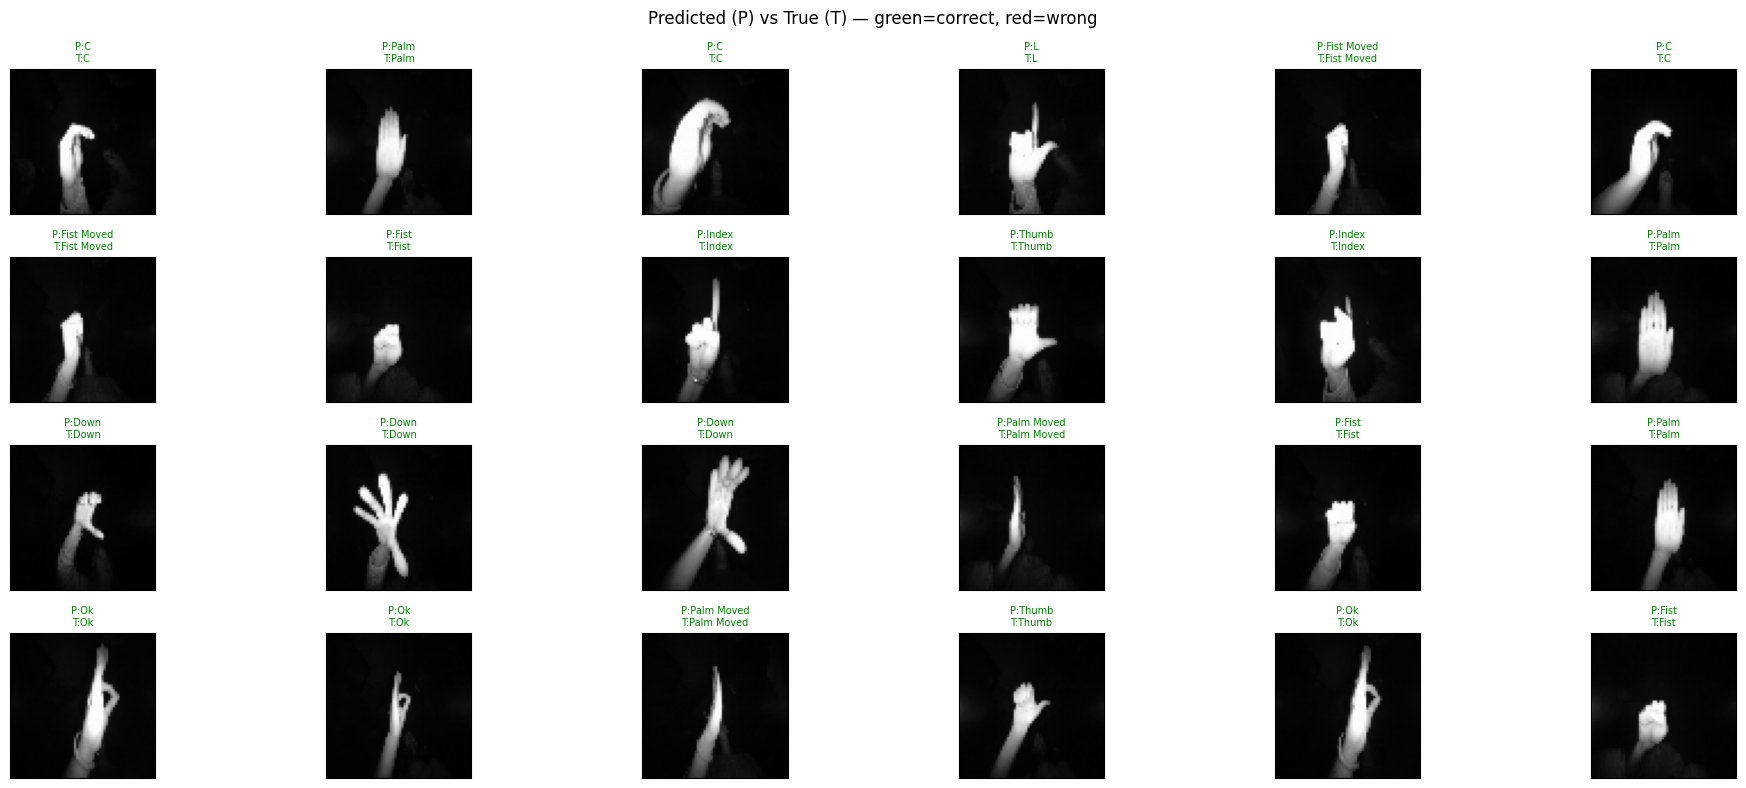

In [ ]:

def check_images(X, y_pred_idx, y_true_oh, label_dict, n=24):
    figure = plt.figure(figsize=(20, 8))
    for i, index in enumerate(np.random.choice(X.shape[0], size=n, replace=False)):
        ax = figure.add_subplot(4, 6, i+1, xticks=[], yticks=[])
        ax.imshow(np.squeeze(X[index]), cmap='gray')
        pred_name = label_dict[y_pred_idx[index]]
        true_name = label_dict[np.argmax(y_true_oh, axis=1)[index]]
        color = 'green' if pred_name == true_name else 'red'
        ax.set_title(f'P:{pred_name}\nT:{true_name}', color=color, fontsize=7)
    plt.suptitle('Predicted (P) vs True (T) — green=correct, red=wrong', fontsize=12)
    plt.tight_layout(); plt.show()

check_images(X_test, y_pred, y_test, GESTURE_NAMES)


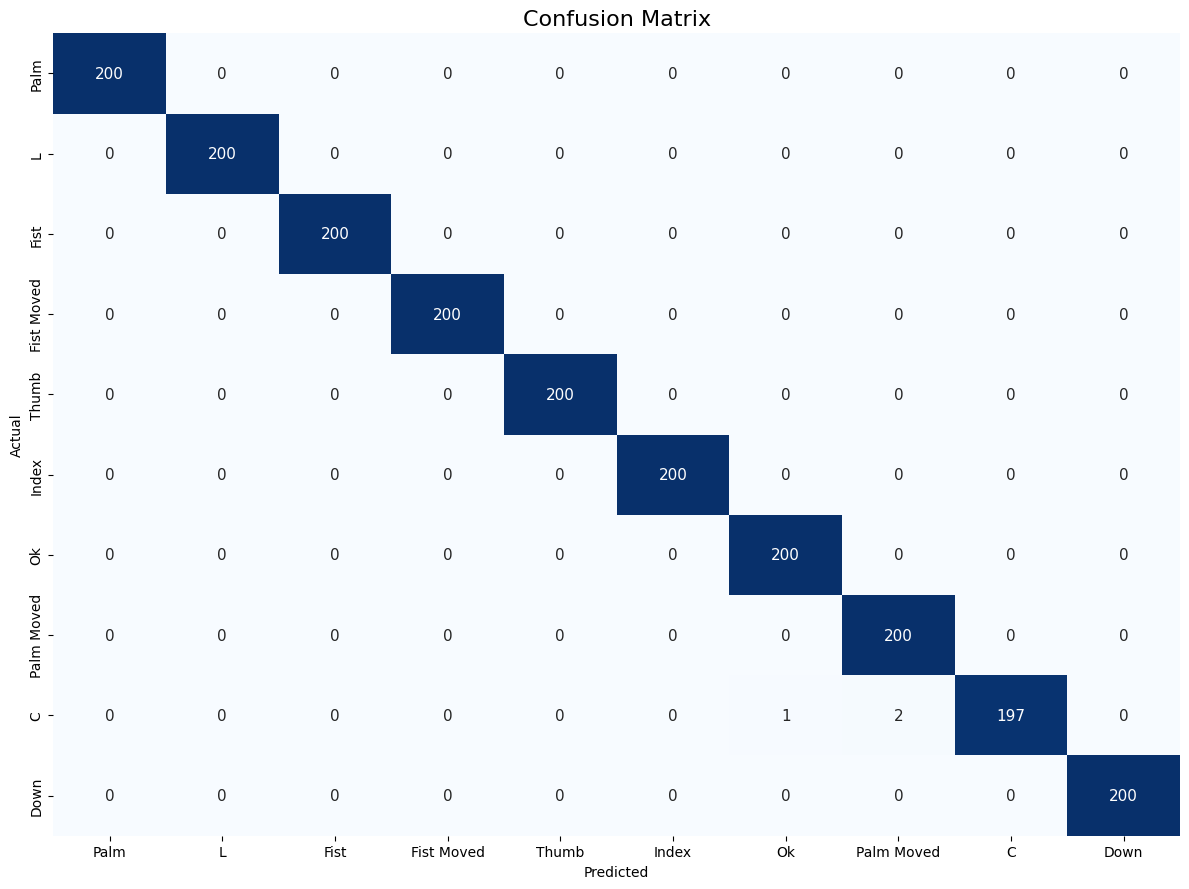

In [ ]:

def conf_mat(y_true_oh, y_pred_idx, class_names):
    cm_data = confusion_matrix(np.argmax(y_true_oh, axis=1), y_pred_idx)
    cm      = pd.DataFrame(cm_data, columns=class_names, index=class_names)
    cm.index.name   = 'Actual'
    cm.columns.name = 'Predicted'
    plt.figure(figsize=(12, 9))
    plt.title('Confusion Matrix', fontsize=16)
    sns.heatmap(cm, cbar=False, cmap='Blues', annot=True,
                annot_kws={'size': 11}, fmt='g')
    plt.tight_layout(); plt.show()

CLASS_NAMES = [GESTURE_NAMES[i] for i in range(10)]
conf_mat(y_test, y_pred, CLASS_NAMES)


In [ ]:

print("=== Base CNN – Classification Report ===")
print(classification_report(np.argmax(y_test, axis=1), y_pred,
                             target_names=CLASS_NAMES, digits=3))


=== Base CNN – Classification Report ===
              precision    recall  f1-score   support

        Palm      1.000     1.000     1.000       200
           L      1.000     1.000     1.000       200
        Fist      1.000     1.000     1.000       200
  Fist Moved      1.000     1.000     1.000       200
       Thumb      1.000     1.000     1.000       200
       Index      1.000     1.000     1.000       200
          Ok      0.995     1.000     0.998       200
  Palm Moved      0.990     1.000     0.995       200
           C      1.000     0.985     0.992       200
        Down      1.000     1.000     1.000       200

    accuracy                          0.999      2000
   macro avg      0.999     0.998     0.998      2000
weighted avg      0.999     0.999     0.998      2000



In [ ]:

for name, X, y in [('Train', X_train, y_train),
                   ('Val',   X_val,   y_val),
                   ('Test',  X_test,  y_test)]:
    loss, acc = model.evaluate(X, y, verbose=0)
    print(f"On {name:5s} Data → Loss: {loss:.4f}  |  Accuracy: {acc*100:.2f}%")


On Train Data → Loss: 0.0013  |  Accuracy: 99.98%
On Val   Data → Loss: 0.0007  |  Accuracy: 100.00%
On Test  Data → Loss: 0.0075  |  Accuracy: 99.85%


## **Inception-style CNN**

In [ ]:


def inception_module(x, f1, f3, f5, fpool):
    """Classic Inception module with 4 parallel branches"""

    b1 = Conv2D(f1, (1,1), padding='same', activation='relu')(x)


    b3 = Conv2D(f3//2, (1,1), padding='same', activation='relu')(x)
    b3 = Conv2D(f3,    (3,3), padding='same', activation='relu')(b3)


    b5 = Conv2D(f5//2, (1,1), padding='same', activation='relu')(x)
    b5 = Conv2D(f5,    (5,5), padding='same', activation='relu')(b5)


    bm = MaxPooling2D((3,3), strides=(1,1), padding='same')(x)
    bm = Conv2D(fpool, (1,1), padding='same', activation='relu')(bm)

    return Concatenate()([b1, b3, b5, bm])

def inception_model():
    inp = Input(shape=(IMG_SIZE, IMG_SIZE, 1))

    x = Conv2D(32, (3,3), padding='same', activation='relu')(inp)
    x = MaxPooling2D((2,2))(x); x = Dropout(0.2)(x)

    x = inception_module(x, f1=16, f3=32, f5=8, fpool=8)
    x = MaxPooling2D((2,2))(x); x = Dropout(0.25)(x)

    x = inception_module(x, f1=32, f3=64, f5=16, fpool=16)
    x = MaxPooling2D((2,2))(x); x = Dropout(0.25)(x)

    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x); x = Dropout(0.5)(x)
    out = Dense(10, activation='softmax')(x)
    return Model(inp, out, name='Inception_style')

inception = inception_model()
inception.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
inception.summary()


Model: "Inception_style"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 64, 64,    │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 32, 32,    │          0 │ conv2d_9[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 32, 32,    │          0 │ max_pooling2d_3[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 32, 32,    │        528 │ dropout_4[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 32, 32, 4) │        132 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 32, 32,    │          0 │ dropout_4[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 32, 32,    │        528 │ dropout_4[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 32, 32,    │      4,640 │ conv2d_11[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 32, 32, 8) │        808 │ conv2d_13[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 32, 32, 8) │        264 │ max_pooling2d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 32, 32,    │          0 │ conv2d_10[0][0],  │
│ (Concatenate)       │ 64)               │            │ conv2d_12[0][0],  │
│                     │                   │            │ conv2d_14[0][0],  │
│                     │                   │            │ conv2d_15[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 16, 16,    │          0 │ concatenate_3[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 16, 16,    │          0 │ max_pooling2d_5[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 16, 16,    │      2,080 │ dropout_5[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 16, 16, 8) │        520 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 16, 16,    │          0 │ dropout_5[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 70,246 (274.40 KB)

 Trainable params: 70,246 (274.40 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

cb_inc = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_inception.h5', monitor='val_accuracy', save_best_only=True, verbose=0)
]
history_inc = inception.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50, batch_size=64,
    callbacks=cb_inc, verbose=1
)


Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1424 - loss: 2.2169

250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.2081 - loss: 2.0797 - val_accuracy: 0.5025 - val_loss: 1.6026
Epoch 2/50
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4592 - loss: 1.4558

250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5401 - loss: 1.2288 - val_accuracy: 0.6870 - val_loss: 0.7509
Epoch 3/50
248/250 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7755 - loss: 0.6298

250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8163 - loss: 0.5260 - val_accuracy: 0.9415 - val_loss: 0.2198
Epoch 4/50
247/250 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8893 - loss: 0.3229

250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9001 - loss: 0.2905 - val_accuracy: 0.9745 - val_loss: 0.1118
Epoch 5/50
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9311 - loss: 0.2009

...

250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9621 - loss: 0.1127 - val_accuracy: 0.9940 - val_loss: 0.0299
Epoch 8/50
248/250 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9663 - loss: 0.1059

250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9676 - loss: 0.0989 - val_accuracy: 0.9960 - val_loss: 0.0261
Epoch 9/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9762 - loss: 0.0718 - val_accuracy: 0.9925 - val_loss: 0.0334
Epoch 10/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9800 - loss: 0.0588

250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9797 - loss: 0.0620 - val_accuracy: 0.9985 - val_loss: 0.0095
Epoch 11/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9833 - loss: 0.0537 - val_accuracy: 0.9985 - val_loss: 0.0056
Epoch 12/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9843 - loss: 0.0504 - val_accuracy: 0.9965 - val_loss: 0.0147
Epoch 13/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9862 - loss: 0.0445 - val_accuracy: 0.9980 - val_loss: 0.0086
Epoch 14/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9855 - loss: 0.0454 - val_accuracy: 0.9970 - val_loss: 0.0110
Epoch 15/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9877 - loss: 0.0398

250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9894 - loss: 0.0343 - val_accuracy: 0.9995 - val_loss: 0.0016
Epoch 16/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9898 - loss: 0.0339 - val_accuracy: 0.9995 - val_loss: 0.0030
Epoch 17/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9894 - loss: 0.0339 - val_accuracy: 0.9990 - val_loss: 0.0030
Epoch 18/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9919 - loss: 0.0295 - val_accuracy: 0.9995 - val_loss: 0.0025
Epoch 19/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9918 - loss: 0.0260 - val_accuracy: 0.9995 - val_loss: 0.0036
Epoch 20/50
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9951 - loss: 0.0181

250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9944 - loss: 0.0206 - val_accuracy: 1.0000 - val_loss: 8.6197e-04
Epoch 21/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9932 - loss: 0.0242 - val_accuracy: 1.0000 - val_loss: 0.0016
Epoch 22/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9942 - loss: 0.0197 - val_accuracy: 0.9995 - val_loss: 0.0011
Epoch 23/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9917 - loss: 0.0258 - val_accuracy: 0.9980 - val_loss: 0.0059
Epoch 24/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9924 - loss: 0.0234 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 25/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9939 - loss: 0.0213 - val_accuracy: 0.9995 - val_loss: 0.0013
Epoch 26/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9937 - loss: 0.0206 - val_accuracy: 1.0000 - val_loss: 2.8114e-04
Epoch 27/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9946 - loss: 0.0169 - val_

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
=== Inception-style CNN – Classification Report ===
              precision    recall  f1-score   support

        Palm      1.000     1.000     1.000       200
           L      1.000     0.995     0.997       200
        Fist      1.000     1.000     1.000       200
  Fist Moved      1.000     1.000     1.000       200
       Thumb      1.000     1.000     1.000       200
       Index      0.995     1.000     0.998       200
          Ok      1.000     1.000     1.000       200
  Palm Moved      0.990     1.000     0.995       200
           C      1.000     0.990     0.995       200
        Down      1.000     1.000     1.000       200

    accuracy                          0.999      2000
   macro avg      0.999     0.998     0.998      2000
weighted avg      0.999     0.999     0.998      2000



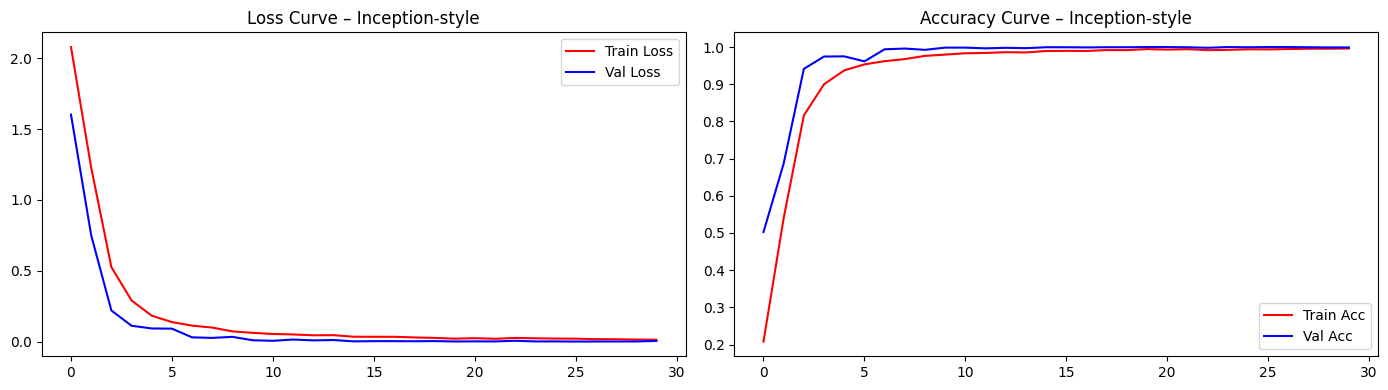

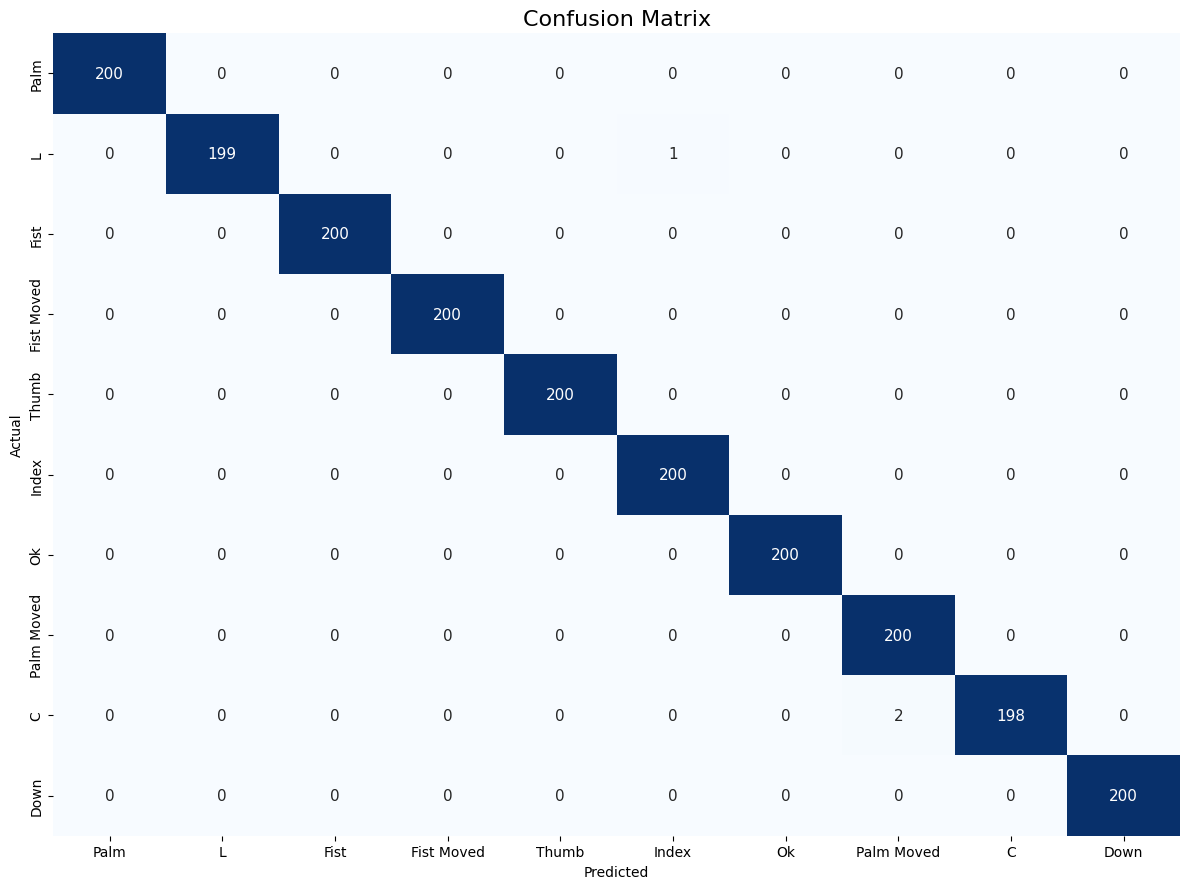

In [ ]:

preds_inc  = inception.predict(X_test)
y_pred_inc = np.argmax(preds_inc, axis=1)
print("=== Inception-style CNN – Classification Report ===")
print(classification_report(np.argmax(y_test, axis=1), y_pred_inc,
                             target_names=CLASS_NAMES, digits=3))
loss_plot(history_inc, '– Inception-style')
conf_mat(y_test, y_pred_inc, CLASS_NAMES)


##  **DenseNet-style CNN (Dense Connections)**

In [ ]:


def dense_block(x, n_layers, growth_rate=16):
    """Dense block: each layer receives concatenation of all previous outputs"""
    feature_list = [x]
    for _ in range(n_layers):
        h = BatchNormalization()(Concatenate()(feature_list) if len(feature_list)>1 else feature_list[0])
        h = Activation('relu')(h)
        h = Conv2D(growth_rate, (3,3), padding='same', use_bias=False)(h)
        h = Dropout(0.1)(h)
        feature_list.append(h)
    return Concatenate()(feature_list)

def transition_block(x, compression=0.5):
    """Transition layer: BN → Conv 1×1 → AvgPool to reduce size"""
    filters = max(1, int(x.shape[-1] * compression))
    x = BatchNormalization()(x); x = Activation('relu')(x)
    x = Conv2D(filters, (1,1), padding='same', use_bias=False)(x)
    x = tf.keras.layers.AveragePooling2D((2,2))(x)
    return x

def densenet_model():
    inp = Input(shape=(IMG_SIZE, IMG_SIZE, 1))
    x = Conv2D(32, (3,3), padding='same', use_bias=False)(inp)
    x = BatchNormalization()(x); x = Activation('relu')(x)

    x = dense_block(x, n_layers=4, growth_rate=16)
    x = transition_block(x)

    x = dense_block(x, n_layers=4, growth_rate=16)
    x = transition_block(x)

    x = dense_block(x, n_layers=4, growth_rate=16)

    x = BatchNormalization()(x); x = Activation('relu')(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x); x = Dropout(0.5)(x)
    out = Dense(10, activation='softmax')(x)
    return Model(inp, out, name='DenseNet_style')

densenet = densenet_model()
densenet.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
densenet.summary()


Model: "DenseNet_style"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 64, 64,    │        288 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ activation_9[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 64, 64,    │      4,608 │ activation_10[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 64, 64,    │          0 │ conv2d_23[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 64, 64,    │          0 │ activation_9[0][… │
│ (Concatenate)       │ 48)               │            │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        192 │ concatenate_5[0]… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 64, 64,    │      6,912 │ activation_11[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 64, 64,    │          0 │ conv2d_24[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 64, 64,    │          0 │ activation_9[0][… │
│ (Concatenate)       │ 64)               │            │ dropout_8[0][0],  │
│                     │                   │            │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ concatenate_6[0]… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 152,522 (595.79 KB)

 Trainable params: 150,138 (586.48 KB)

 Non-trainable params: 2,384 (9.31 KB)

In [ ]:

cb_den = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_densenet.h5', monitor='val_accuracy', save_best_only=True, verbose=0)
]
history_den = densenet.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50, batch_size=64,
    callbacks=cb_den, verbose=1
)


Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5454 - loss: 1.4212

250/250 ━━━━━━━━━━━━━━━━━━━━ 60s 106ms/step - accuracy: 0.7776 - loss: 0.7803 - val_accuracy: 0.1005 - val_loss: 5.5064
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9891 - loss: 0.0769

250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 79ms/step - accuracy: 0.9910 - loss: 0.0595 - val_accuracy: 0.3530 - val_loss: 1.9904
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9914 - loss: 0.0409

250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 76ms/step - accuracy: 0.9939 - loss: 0.0304 - val_accuracy: 0.7825 - val_loss: 0.7501
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 76ms/step - accuracy: 0.9948 - loss: 0.0227 - val_accuracy: 0.3120 - val_loss: 7.2332
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9934 - loss: 0.0264

250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 79ms/step - accuracy: 0.9958 - loss: 0.0189 - val_accuracy: 0.8105 - val_loss: 0.5084
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 78ms/step - accuracy: 0.9979 - loss: 0.0105 - val_accuracy: 0.4260 - val_loss: 5.3928
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9943 - loss: 0.0234

250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - accuracy: 0.9962 - loss: 0.0166 - val_accuracy: 0.9595 - val_loss: 0.1256
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9993 - loss: 0.0055

250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - accuracy: 0.9994 - loss: 0.0044 - val_accuracy: 0.9985 - val_loss: 0.0026
Epoch 9/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - accuracy: 0.9954 - loss: 0.0202 - val_accuracy: 0.9580 - val_loss: 0.1132
Epoch 10/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - accuracy: 0.9971 - loss: 0.0127 - val_accuracy: 0.8850 - val_loss: 0.4114
Epoch 11/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - accuracy: 0.9992 - loss: 0.0042 - val_accuracy: 0.5185 - val_loss: 3.4550
Epoch 12/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 76ms/step - accuracy: 0.9966 - loss: 0.0110 - val_accuracy: 0.9260 - val_loss: 0.3550
Epoch 13/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9990 - loss: 0.0039

250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - accuracy: 0.9981 - loss: 0.0061 - val_accuracy: 1.0000 - val_loss: 5.2569e-04
Epoch 14/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - accuracy: 0.9992 - loss: 0.0043 - val_accuracy: 0.9980 - val_loss: 0.0074
Epoch 15/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - accuracy: 0.9987 - loss: 0.0045 - val_accuracy: 0.9695 - val_loss: 0.0941
Epoch 16/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - accuracy: 0.9965 - loss: 0.0119 - val_accuracy: 0.9995 - val_loss: 0.0021
Epoch 17/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 78ms/step - accuracy: 0.9974 - loss: 0.0096 - val_accuracy: 0.7130 - val_loss: 1.9023
Epoch 18/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - accuracy: 0.9987 - loss: 0.0054 - val_accuracy: 0.9995 - val_loss: 0.0023
Epoch 19/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - accuracy: 0.9992 - loss: 0.0030 - val_accuracy: 0.7080 - val_loss: 2.1355
Epoch 20/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - accuracy: 0.9973 - loss: 0.0100 - 

63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step
=== DenseNet-style CNN – Classification Report ===
              precision    recall  f1-score   support

        Palm      1.000     1.000     1.000       200
           L      1.000     1.000     1.000       200
        Fist      1.000     1.000     1.000       200
  Fist Moved      1.000     1.000     1.000       200
       Thumb      1.000     1.000     1.000       200
       Index      1.000     1.000     1.000       200
          Ok      1.000     1.000     1.000       200
  Palm Moved      0.995     1.000     0.998       200
           C      1.000     0.995     0.997       200
        Down      1.000     1.000     1.000       200

    accuracy                          1.000      2000
   macro avg      1.000     0.999     0.999      2000
weighted avg      1.000     1.000     0.999      2000



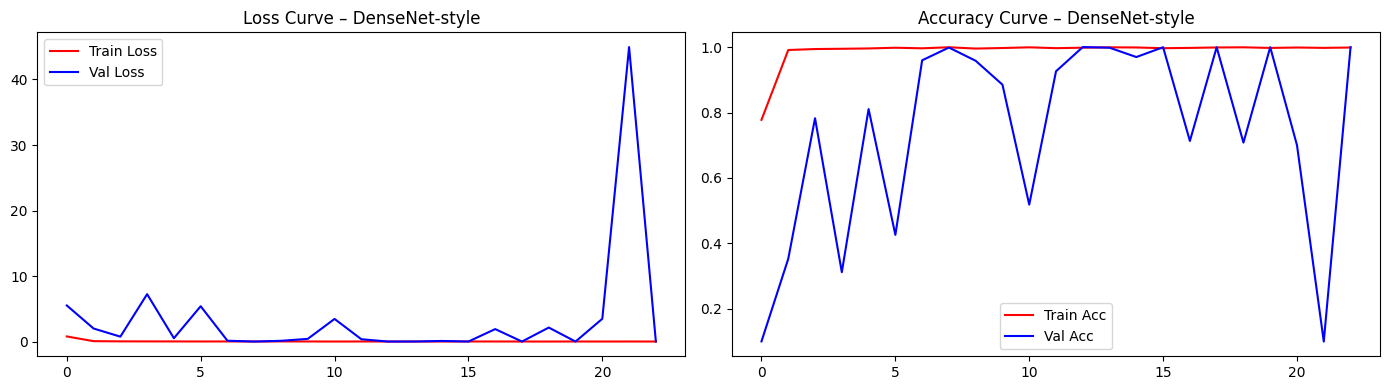

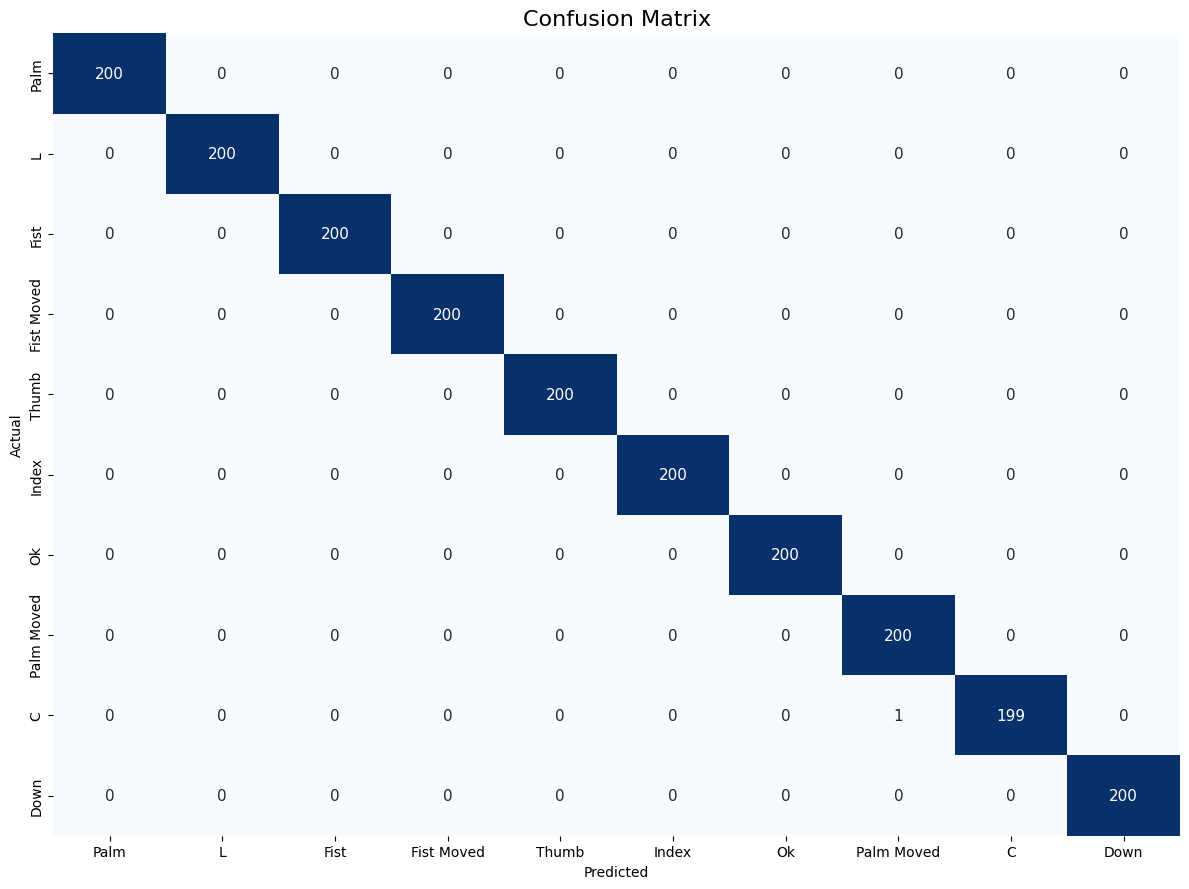

In [ ]:

preds_den  = densenet.predict(X_test)
y_pred_den = np.argmax(preds_den, axis=1)
print("=== DenseNet-style CNN – Classification Report ===")
print(classification_report(np.argmax(y_test, axis=1), y_pred_den,
                             target_names=CLASS_NAMES, digits=3))
loss_plot(history_den, '– DenseNet-style')
conf_mat(y_test, y_pred_den, CLASS_NAMES)


## **Squeeze-and-Excitation (SE) CNN**

In [ ]:


def se_block(x, ratio=16):
    """Squeeze-and-Excitation block: channel-wise feature recalibration"""
    ch  = x.shape[-1]
    sq  = GlobalAveragePooling2D()(x)
    ex  = Dense(max(ch//ratio, 1), activation='relu')(sq)
    ex  = Dense(ch,               activation='sigmoid')(ex)
    ex  = Reshape((1, 1, ch))(ex)
    return Multiply()([x, ex])

def se_conv_block(x, filters, stride=1):
    """Conv → BN → ReLU → SE block"""
    x = Conv2D(filters, (3,3), strides=stride, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x); x = Activation('relu')(x)
    x = se_block(x)
    return x

def se_model():
    inp = Input(shape=(IMG_SIZE, IMG_SIZE, 1))

    x = Conv2D(32, (3,3), padding='same', use_bias=False)(inp)
    x = BatchNormalization()(x); x = Activation('relu')(x)

    x = se_conv_block(x, 32);  x = MaxPooling2D((2,2))(x); x = Dropout(0.2)(x)
    x = se_conv_block(x, 64);  x = MaxPooling2D((2,2))(x); x = Dropout(0.25)(x)
    x = se_conv_block(x, 128); x = MaxPooling2D((2,2))(x); x = Dropout(0.25)(x)
    x = se_conv_block(x, 256)

    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x); x = Dropout(0.5)(x)
    out = Dense(10, activation='softmax')(x)
    return Model(inp, out, name='SE_CNN')

se_net = se_model()
se_net.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
se_net.summary()


Model: "SE_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, 64, 64,    │        288 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_37[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_25       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 64, 64,    │      9,216 │ activation_25[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_38[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_26       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ activation_26[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 2)         │         66 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 32)        │         96 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 32)  │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 64, 64,    │          0 │ activation_26[0]… │
│                     │ 32)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 32, 32,    │          0 │ multiply[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_21          │ (None, 32, 32,    │          0 │ max_pooling2d_8[… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 32, 32,    │     18,432 │ dropout_21[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_39[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_27       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ activation_27[0]

 Total params: 478,376 (1.82 MB)

 Trainable params: 477,352 (1.82 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [ ]:

cb_se = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_se.h5', monitor='val_accuracy', save_best_only=True, verbose=0)
]
history_se = se_net.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50, batch_size=64,
    callbacks=cb_se, verbose=1
)


Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5846 - loss: 1.2147

250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.8087 - loss: 0.5898 - val_accuracy: 0.1660 - val_loss: 4.3244
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9858 - loss: 0.0566

250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9872 - loss: 0.0461 - val_accuracy: 0.3620 - val_loss: 3.9641
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9915 - loss: 0.0280

250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9932 - loss: 0.0272 - val_accuracy: 0.8500 - val_loss: 0.4775
Epoch 4/50
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9933 - loss: 0.0273

250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9948 - loss: 0.0206 - val_accuracy: 0.9500 - val_loss: 0.1275
Epoch 5/50
248/250 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9956 - loss: 0.0170

250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9957 - loss: 0.0165 - val_accuracy: 0.9975 - val_loss: 0.0071
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9939 - loss: 0.0218 - val_accuracy: 0.9810 - val_loss: 0.0648
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9974 - loss: 0.0096 - val_accuracy: 0.9910 - val_loss: 0.0320
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9975 - loss: 0.0085 - val_accuracy: 0.9935 - val_loss: 0.0218
Epoch 9/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9973 - loss: 0.0096 - val_accuracy: 0.9975 - val_loss: 0.0068
Epoch 10/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9983 - loss: 0.0063 - val_accuracy: 0.9415 - val_loss: 0.1884
Epoch 11/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9959 - loss: 0.0137 - val_accuracy: 0.9975 - val_loss: 0.0085
Epoch 12/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9983 - loss: 0.0061 - val_accuracy: 0.

250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9991 - loss: 0.0043 - val_accuracy: 1.0000 - val_loss: 6.6363e-06
Epoch 14/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9965 - loss: 0.0107 - val_accuracy: 1.0000 - val_loss: 7.7019e-04
Epoch 15/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9973 - loss: 0.0095 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 16/50
150/250 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9981 - loss: 0.0071

In [ ]:

preds_se  = se_net.predict(X_test)
y_pred_se = np.argmax(preds_se, axis=1)
print("=== SE-CNN – Classification Report ===")
print(classification_report(np.argmax(y_test, axis=1), y_pred_se,
                             target_names=CLASS_NAMES, digits=3))
loss_plot(history_se, '– SE-CNN')
conf_mat(y_test, y_pred_se, CLASS_NAMES)


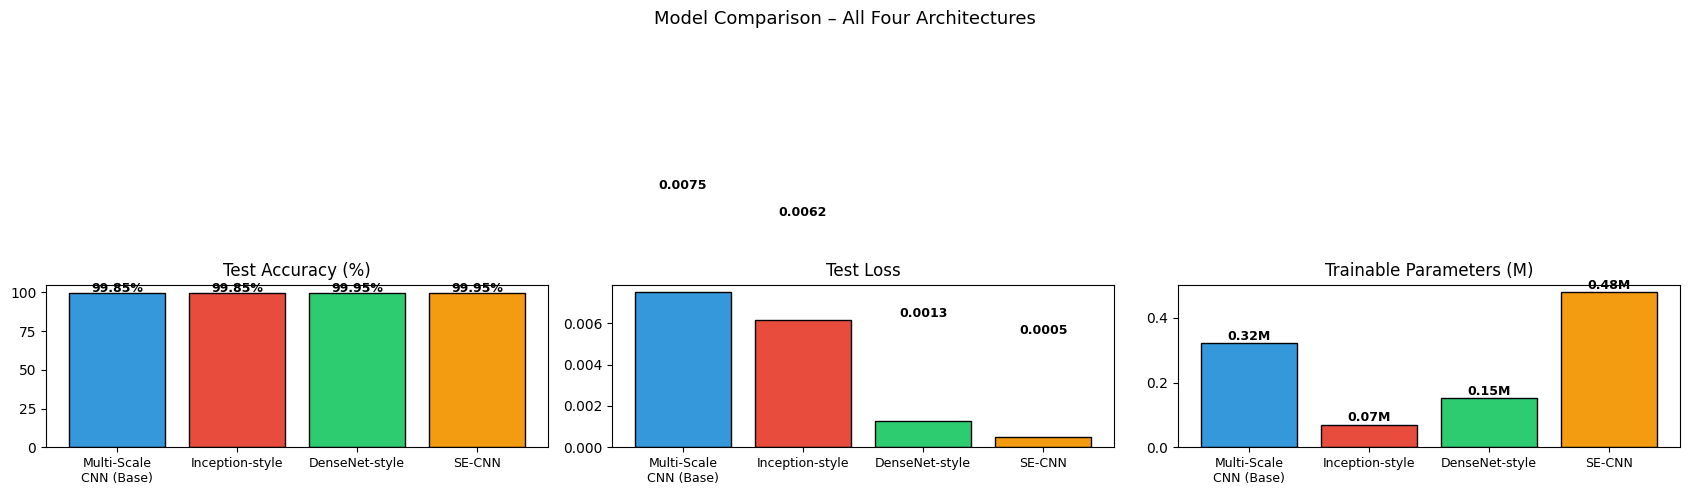


Model                        Test Acc   Test Loss       Params
--------------------------------------------------------------
Multi-Scale CNN (Base)         99.85%      0.0075      322,682
Inception-style                99.85%      0.0062       70,246
DenseNet-style                 99.95%      0.0013      152,522
SE-CNN                         99.95%      0.0005      478,376


In [ ]:

model_names = ['Multi-Scale\nCNN (Base)', 'Inception-style', 'DenseNet-style', 'SE-CNN']

def eval_model_metrics(m):
    loss, acc = m.evaluate(X_test, y_test, verbose=0)
    return acc, loss

acc_base,  loss_base  = eval_model_metrics(model)
acc_inc,   loss_inc   = eval_model_metrics(inception)
acc_den,   loss_den   = eval_model_metrics(densenet)
acc_se,    loss_se    = eval_model_metrics(se_net)

accs   = [acc_base, acc_inc, acc_den, acc_se]
losses = [loss_base, loss_inc, loss_den, loss_se]
params = [model.count_params(), inception.count_params(),
          densenet.count_params(), se_net.count_params()]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
x = np.arange(len(model_names))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].bar(x, [a*100 for a in accs], color=colors, edgecolor='black')
axes[0].set_xticks(x); axes[0].set_xticklabels(model_names, fontsize=9)
axes[0].set_title('Test Accuracy (%)', fontsize=12); axes[0].set_ylim(0, 105)
for xi, a in zip(x, accs):
    axes[0].text(xi, a*100+0.5, f'{a*100:.2f}%', ha='center', fontsize=9, fontweight='bold')

axes[1].bar(x, losses, color=colors, edgecolor='black')
axes[1].set_xticks(x); axes[1].set_xticklabels(model_names, fontsize=9)
axes[1].set_title('Test Loss', fontsize=12)
for xi, l in zip(x, losses):
    axes[1].text(xi, l+0.005, f'{l:.4f}', ha='center', fontsize=9, fontweight='bold')

axes[2].bar(x, [p/1e6 for p in params], color=colors, edgecolor='black')
axes[2].set_xticks(x); axes[2].set_xticklabels(model_names, fontsize=9)
axes[2].set_title('Trainable Parameters (M)', fontsize=12)
for xi, p in zip(x, params):
    axes[2].text(xi, p/1e6+0.01, f'{p/1e6:.2f}M', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Comparison – All Four Architectures', fontsize=13)
plt.tight_layout(); plt.show()

print("\n{:<26} {:>10} {:>11} {:>12}".format('Model', 'Test Acc', 'Test Loss', 'Params'))
print("-"*62)
for name, a, l, p in zip(model_names, accs, losses, params):
    print(f"{name.replace(chr(10),' '):<26} {a*100:>9.2f}% {l:>11.4f} {p:>12,}")


In [ ]:

best_idx   = int(np.argmax(accs))
best_model = [model, inception, densenet, se_net][best_idx]
best_name  = model_names[best_idx].replace('\n', ' ')


model_constructors = [cnn_model, inception_model, densenet_model, se_model]

print(f"\n✓ Best model: {best_name}")
print(f"  Test Accuracy : {accs[best_idx]*100:.2f}%")
print(f"  Test Loss     : {losses[best_idx]:.4f}")
print(f"  Parameters    : {params[best_idx]:,}")
print("\nProceeding to fine-tune the best model...")



✓ Best model: DenseNet-style
  Test Accuracy : 99.95%
  Test Loss     : 0.0013
  Parameters    : 152,522

Proceeding to fine-tune the best model...


# **Fine Tuning – Best Model**



## Fine Tuning 1 – Lower Learning Rate + More Epochs

In [ ]:

ft_model_1 = model_constructors[best_idx]()
ft_model_1.compile(optimizer=Adam(learning_rate=1e-4),
                   loss='categorical_crossentropy', metrics=['accuracy'])

cb_ft1 = [
    EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_ft1.h5', monitor='val_accuracy', save_best_only=True, verbose=0)
]
history_ft1 = ft_model_1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80, batch_size=64,
    callbacks=cb_ft1, verbose=1
)


In [ ]:
loss_plot(history_ft1, '– Fine Tune 1 (LR=1e-4)')
preds_ft1  = ft_model_1.predict(X_test)
y_pred_ft1 = np.argmax(preds_ft1, axis=1)
loss_ft1, acc_ft1 = ft_model_1.evaluate(X_test, y_test, verbose=0)
print(f"Fine Tune 1 → Test Accuracy: {acc_ft1*100:.2f}%  |  Test Loss: {loss_ft1:.4f}")
print(classification_report(np.argmax(y_test, axis=1), y_pred_ft1,
                             target_names=CLASS_NAMES, digits=3))


## Fine Tuning 2 – Data Augmentation (Flip, Zoom, Rotation, Brightness)

In [ ]:

datagen = ImageDataGenerator(
    horizontal_flip=True,
    zoom_range=0.15,
    rotation_range=15,
    brightness_range=[0.8, 1.2],
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='nearest'
)
datagen.fit(X_train)

ft_model_2 = model_constructors[best_idx]()
ft_model_2.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

cb_ft2 = [
    EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_ft2.h5', monitor='val_accuracy', save_best_only=True, verbose=0)
]

BATCH = 64
history_ft2 = ft_model_2.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH),
    steps_per_epoch=len(X_train) // BATCH,
    validation_data=(X_val, y_val),
    epochs=60,
    callbacks=cb_ft2, verbose=1
)


In [ ]:
loss_plot(history_ft2, '– Fine Tune 2 (Augmentation)')
preds_ft2  = ft_model_2.predict(X_test)
y_pred_ft2 = np.argmax(preds_ft2, axis=1)
loss_ft2, acc_ft2 = ft_model_2.evaluate(X_test, y_test, verbose=0)
print(f"Fine Tune 2 → Test Accuracy: {acc_ft2*100:.2f}%  |  Test Loss: {loss_ft2:.4f}")
print(classification_report(np.argmax(y_test, axis=1), y_pred_ft2,
                             target_names=CLASS_NAMES, digits=3))


## Fine Tuning 3 – Cosine-Decay LR + Augmentation + L2 Regularisation

In [ ]:

ft_model_3 = model_constructors[best_idx]()

total_epochs = 70
lr_sched = tf.keras.experimental.CosineDecay(
    1e-3, decay_steps=total_epochs * (len(X_train)//64))

ft_model_3.compile(optimizer=Adam(learning_rate=lr_sched),
                   loss='categorical_crossentropy', metrics=['accuracy'])

cb_ft3 = [
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_ft3.h5', monitor='val_accuracy', save_best_only=True, verbose=0)
]

history_ft3 = ft_model_3.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    steps_per_epoch=len(X_train)//64,
    validation_data=(X_val, y_val),
    epochs=total_epochs,
    callbacks=cb_ft3, verbose=1
)


In [ ]:
loss_plot(history_ft3, '– Fine Tune 3 (Cosine + Aug + L2)')
preds_ft3  = ft_model_3.predict(X_test)
y_pred_ft3 = np.argmax(preds_ft3, axis=1)
loss_ft3, acc_ft3 = ft_model_3.evaluate(X_test, y_test, verbose=0)
print(f"Fine Tune 3 → Test Accuracy: {acc_ft3*100:.2f}%  |  Test Loss: {loss_ft3:.4f}")
print(classification_report(np.argmax(y_test, axis=1), y_pred_ft3,
                             target_names=CLASS_NAMES, digits=3))


## Fine Tuning Comparison – Base vs FT1 vs FT2 vs FT3

In [ ]:

base_loss, base_acc_test = best_model.evaluate(X_test, y_test, verbose=0)

ft_names = [f'Base\n{best_name}', 'FT1\nLow LR', 'FT2\nAugment', 'FT3\nCosine+L2']
ft_accs  = [base_acc_test, acc_ft1, acc_ft2, acc_ft3]
ft_losses= [base_loss,     loss_ft1,loss_ft2, loss_ft3]
colors   = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
x = np.arange(4)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, vals, title, ylabel in zip(
        axes,
        [[a*100 for a in ft_accs], ft_losses],
        ['Test Accuracy (%)', 'Test Loss'],
        ['Accuracy (%)', 'Loss']):
    bars = ax.bar(x, vals, color=colors, edgecolor='black')
    ax.set_xticks(x); ax.set_xticklabels(ft_names, fontsize=10)
    ax.set_title(title, fontsize=12); ax.set_ylabel(ylabel)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle(f'Fine Tuning Comparison – Best Architecture: {best_name}', fontsize=13)
plt.tight_layout(); plt.show()

print("\n{:<20} {:>12} {:>12}".format('Strategy', 'Test Acc', 'Test Loss'))
print("-"*46)
for n, a, l in zip(ft_names, ft_accs, ft_losses):
    print(f"{n.replace(chr(10),' '):<20} {a*100:>11.2f}% {l:>12.4f}")


# Model Saving

In [ ]:

best_ft_idx  = int(np.argmax([base_acc_test, acc_ft1, acc_ft2, acc_ft3]))
best_ft_models = [best_model, ft_model_1, ft_model_2, ft_model_3]
final_model  = best_ft_models[best_ft_idx]

model_json = final_model.to_json()
with open("gesture_model.json", "w") as json_file:
    json_file.write(model_json)
final_model.save_weights("gesture_model_weights.h5")
final_model.save("gesture_model_full.h5")
print(f"Saved final model (strategy idx={best_ft_idx}) to disk ✓")


# Real-Time Inference using OpenCV



## Loading saved model architecture and weights

In [ ]:

import cv2, numpy as np
from tensorflow.keras.models import model_from_json

model_loaded = model_from_json(open("gesture_model.json", "r").read())
model_loaded.load_weights("gesture_model_weights.h5")
print("Model loaded from disk ✓")


## OpenCV Webcam Loop for Real-Time Gesture Prediction

In [ ]:

import cv2, numpy as np

GESTURE_NAMES_LOCAL = {
    0:'Palm', 1:'L', 2:'Fist', 3:'Fist Moved', 4:'Thumb',
    5:'Index', 6:'OK', 7:'Palm Moved', 8:'C', 9:'Down'
}
IMG_SIZE = 64

cap = cv2.VideoCapture(0)
print("Press 'q' to quit.")

while True:
    valid, frame = cap.read()
    if not valid:
        break

    # Pre-process frame
    gray    = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    roi     = gray[80:280, 100:300]
    roi_rs  = cv2.resize(roi, (IMG_SIZE, IMG_SIZE))
    roi_norm = roi_rs.astype('float32') / 255.0
    inp     = roi_norm.reshape(1, IMG_SIZE, IMG_SIZE, 1)

    # Predict
    pred    = model_loaded.predict(inp, verbose=0)
    cls_idx = int(np.argmax(pred))
    label   = GESTURE_NAMES_LOCAL[cls_idx]
    conf    = float(pred[0][cls_idx]) * 100

    # Draw ROI box and label on colour frame
    cv2.rectangle(frame, (100, 80), (300, 280), (0, 255, 0), 2)
    cv2.putText(frame, f'{label} ({conf:.1f}%)', (90, 70),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 0), 2)

    disp = cv2.resize(frame, (900, 600))
    cv2.imshow('Hand Gesture Recognition', disp)

    if cv2.waitKey(10) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
